# 07_hyperparameter_analysis

This notebook analyzes **hyperparameter effects on predictive multiplicity** within the Rashomon set.

**Key Question**

> Which hyperparameters drive observation-wise variance in predictions?

**Approach**

Following supervisor feedback, we define hyperparameter effects **conditionally on the Rashomon set** (only models with L â‰¤ L* + Îµ).

**Variance Decomposition**

For each observation, decompose total variance:
- **Var_total** = Var_between(HP values) + Var_within(HP value)
- **Var_between**: Variance due to changing the hyperparameter
- **Var_within**: Variance due to random seeds or other hyperparameters (given fixed HP value)

**Profiling Approach** (optional)

For comparing hyperparameter effects:
- For each HP value h, find best loss L*(h)
- Define local Rashomon set: models with HP = h and L â‰¤ L*(h) + Îµ
- Note: These are locally optimal given h, not globally equally good.

## 1. Imports

In [10]:
import sys
from pathlib import Path

# Add parent directory to path
project_root = Path.cwd()
if not (project_root / 'analysis').exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import json
from collections import defaultdict

from analysis.hyperparams import (
    parse_hyperparameters,
    variance_decomposition_by_hyperparameter,
    hyperparameter_profiling,
    compute_hp_importance,
    compute_family_importance,
    compute_within_family_hp_importance,
    make_hp_key,
)
from analysis.run_analysis import spatial_analysis
try:
    from analysis.preprocessing import get_transformed_test_features
except ImportError:
    get_transformed_test_features = None

## 2. Parameters (reproducible analysis)

Set these once; all tables and figures use `dataset_name`, `seed`, `eps`, and the analysis parameters below.

In [11]:
# Dataset and run selection
dataset_name = "compas"
seed = 42
eps = 0.01

# Family-specific Rashomon and HV/HH analysis
top_k = 25          # top-k models per family by loss
q = 10              # HV: top q% of variance (within family)
knn_k = 15          # k for kNN graph (same W used for all families)

# Output directories (under project_root)
TABLES_DIR = project_root / "tables"
FIGURES_DIR = project_root / "figures"
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load Rashomon Results

In [12]:
# Resolve result directory from parameters (P and meta required; X_test optional)
REQUIRED = ("P_test.npy", "meta.csv")
results_base = project_root / "results" / dataset_name
candidates = [
    results_base / f"seed={seed}_eps={eps}",
    results_base / f"seed={seed}",
]
if results_base.exists():
    for p in sorted(results_base.iterdir()):
        if p.is_dir() and p not in candidates and all((p / f).exists() for f in REQUIRED):
            candidates.append(p)
            break
BASE_PATH = None
for c in candidates:
    if c.exists() and all((c / f).exists() for f in REQUIRED):
        BASE_PATH = c
        break
assert BASE_PATH is not None, (
    f"No result directory with {REQUIRED} found under {results_base}. Tried: {[str(x) for x in candidates]}."
)

P = np.load(BASE_PATH / "P_test.npy")
meta_raw = pd.read_csv(BASE_PATH / "meta.csv")

# X_test: from file if present, else from preprocessing (for spatial/LISA)
if (BASE_PATH / "X_test.csv").exists():
    X_test = pd.read_csv(BASE_PATH / "X_test.csv")
else:
    assert get_transformed_test_features is not None, "X_test.csv missing and analysis.preprocessing not available"
    X_test_arr = get_transformed_test_features(BASE_PATH, dataset_name)
    X_test = pd.DataFrame(X_test_arr)

# Loss column: first existing from priority list
LOSS_PRIORITY = ["loss", "val_loss", "val_brier", "brier", "brier_mean", "metric_loss", "L"]
loss_col = None
for c in LOSS_PRIORITY:
    if c in meta_raw.columns:
        loss_col = c
        break
assert loss_col is not None, f"No loss column found. Have: {list(meta_raw.columns)}"
print(f"Using loss column: '{loss_col}'")

# Align meta rows with P rows: meta row i <-> P[i]
if "model_id" in meta_raw.columns:
    # Assume model_id gives order; ensure meta is sorted so meta.index matches P row order
    meta_raw = meta_raw.sort_values("model_id").reset_index(drop=True)
# Else: assume meta row i corresponds to P[i] (no reorder)
assert P.shape[0] == len(meta_raw), f"P.shape[0]={P.shape[0]} != len(meta)={len(meta_raw)}"
assert P.shape[1] == X_test.shape[0], f"P.shape[1]={P.shape[1]} != X_test.shape[0]={X_test.shape[0]}"

metrics_path = BASE_PATH / "metrics.npz"
metrics = dict(np.load(metrics_path)) if metrics_path.exists() else {"variance": np.var(P, axis=0, ddof=1)}

print(f"Loaded from: {BASE_PATH}")
print(f"  Models: {P.shape[0]}, Observations: {P.shape[1]}")
print(f"  Meta columns: {list(meta_raw.columns)}")

Using loss column: 'val_brier'
Loaded from: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\results\compas\seed=0
  Models: 250, Observations: 1443
  Meta columns: ['model_name', 'candidate_id', 'candidate_seed', 'hp', 'val_brier', 'outer_seed']


## 3. Parse Hyperparameters

In [13]:
# Parse hyperparameter dictionaries
meta = parse_hyperparameters(meta_raw)

print("Hyperparameters found:")
hp_cols = [c for c in meta.columns if c.startswith('hp_')]
print(f"  {len(hp_cols)} hyperparameters: {[c.replace('hp_', '') for c in hp_cols]}")

# Show model family distribution
print(f"\nModel families:")
print(meta['model_name'].value_counts())

Hyperparameters found:
  24 hyperparameters: ['C', 'activation', 'alpha', 'bootstrap', 'early_stopping', 'hidden_layer_sizes', 'l1_ratio', 'learning_rate', 'learning_rate_init', 'max_depth', 'max_features', 'max_iter', 'min_samples_leaf', 'min_samples_split', 'n_estimators', 'n_iter_no_change', 'n_jobs', 'n_neighbors', 'p', 'penalty', 'solver', 'subsample', 'tol', 'weights']

Model families:
model_name
LogReg    50
kNN       50
RF        50
GBM       50
MLP       50
Name: count, dtype: int64


## 4. Family-specific Rashomon set and HV/HH per family

For each model family, define the family Rashomon set as the **top 25 models** (by loss) within that family. Compute pointwise variance over that set, then:
- **HV (high-variance):** top q% of observations by variance (within that family's variance distribution).
- **HH (highâ€“high LISA hotspots):** LISA run on the family's variance vector using the **same** kNN graph (built once from `X_test` with `k=knn_k`) for all families.

Summary table: `n_models`, `hv_count`, `hh_count`, `overlap_count`, `mean_var`, `moran_I`, `moran_p` per family. Saved to `tables/family_hv_hh_summary_{dataset}.csv`. Bar charts compare `hv_count` and `hh_count` across families.

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\tables\family_hv_hh_summary_compas.csv
family  n_models  hv_count  hh_count  overlap_count  mean_var  moran_I  moran_p
LogReg        25       145         4              4  0.000006 0.123729    0.001
   kNN        25       145        22              9  0.011894 0.114840    0.001
    RF        25       145        71             48  0.003180 0.251715    0.001
   GBM        25       145        41             31  0.001076 0.218481    0.001
   MLP        25       145       181            105  0.001111 0.628525    0.001


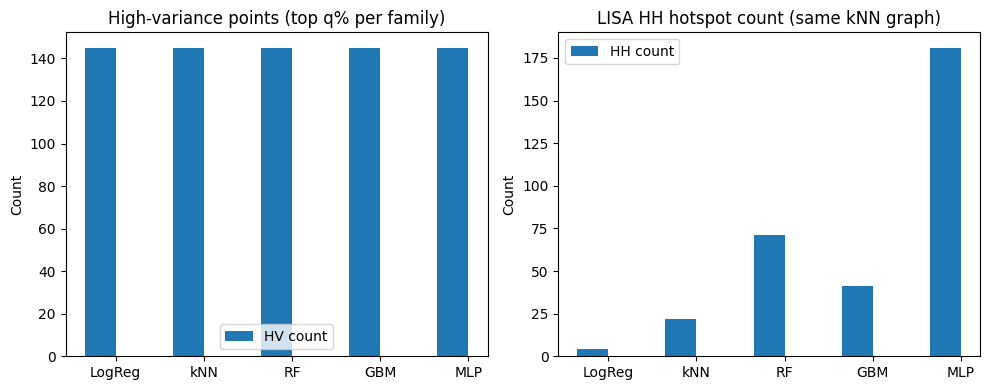

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\family_hv_hh_compas.pdf


In [14]:
# Family-specific Rashomon: top_k per family by loss; same kNN graph for all (X_test, knn_k)
X_test_numeric = X_test.select_dtypes(include=[np.number]) if hasattr(X_test, "select_dtypes") else X_test
if hasattr(X_test_numeric, "values"):
    X_test_numeric = np.asarray(X_test_numeric.values, dtype=float)
else:
    X_test_numeric = np.asarray(X_test_numeric, dtype=float)

family_summary_rows = []
for family in meta["model_name"].unique():
    meta_f = meta[meta["model_name"] == family].copy()
    # Top top_k by ascending loss (row indices into P)
    top_idx = meta_f.nsmallest(min(top_k, len(meta_f)), loss_col).index.tolist()
    P_f = P[top_idx]
    n_models_f = P_f.shape[0]
    var_f = np.var(P_f, axis=0, ddof=1)

    # HV: top q% of var_f (within-family threshold)
    thresh_hv = np.percentile(var_f, 100 - q)
    hv_mask = var_f >= thresh_hv
    hv_count = int(np.sum(hv_mask))

    # HH: LISA with same X_test and k (same W effectively)
    res = spatial_analysis(var_f, X_test_numeric, k=knn_k)
    HH_mask = res["HH_mask"]
    hh_count = int(np.sum(HH_mask))
    overlap_count = int(np.sum(hv_mask & HH_mask))

    family_summary_rows.append({
        "family": family,
        "n_models": n_models_f,
        "hv_count": hv_count,
        "hh_count": hh_count,
        "overlap_count": overlap_count,
        "mean_var": float(np.mean(var_f)),
        "moran_I": res["moran_i"],
        "moran_p": res["moran_p_sim"],
    })

family_hv_hh_summary = pd.DataFrame(family_summary_rows)
out_path = TABLES_DIR / f"family_hv_hh_summary_{dataset_name}.csv"
family_hv_hh_summary.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(family_hv_hh_summary.to_string(index=False))

# Bar charts: hv_count and hh_count across families
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
x = np.arange(len(family_hv_hh_summary))
w = 0.35
ax1.bar(x - w/2, family_hv_hh_summary["hv_count"], w, label="HV count")
ax1.set_xticks(x)
ax1.set_xticklabels(family_hv_hh_summary["family"])
ax1.set_ylabel("Count")
ax1.set_title("High-variance points (top q% per family)")
ax1.legend()
ax2.bar(x - w/2, family_hv_hh_summary["hh_count"], w, label="HH count")
ax2.set_xticks(x)
ax2.set_xticklabels(family_hv_hh_summary["family"])
ax2.set_ylabel("Count")
ax2.set_title("LISA HH hotspot count (same kNN graph)")
ax2.legend()
plt.tight_layout()
fig_path = FIGURES_DIR / f"family_hv_hh_{dataset_name}.pdf"
plt.savefig(fig_path)
plt.show()
print(f"Saved: {fig_path}")

## 5. Within-family hyperparameter range effects (which HP ranges have more HV/HH?)

For each family and each hyperparameter column in that family's meta: bin numeric HPs (>5 unique values) into quantiles (e.g. 4 bins), else treat as categorical. For each group/bin, compute variance over models in that group; use the **family-level HV threshold** (option A) for fair comparison. Compute `hv_count`, `hh_count` (LISA with same kNN), `overlap_count`, `mean_var` per group. Save `tables/hp_range_effects_{dataset}_{family}.csv` and for each HP a figure `figures/hp_range_effects_{dataset}_{family}_{hp}.pdf` (x = bin/value, y = hv_count and hh_count, n_models annotated).

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\tables\hp_range_effects_compas_LogReg.csv


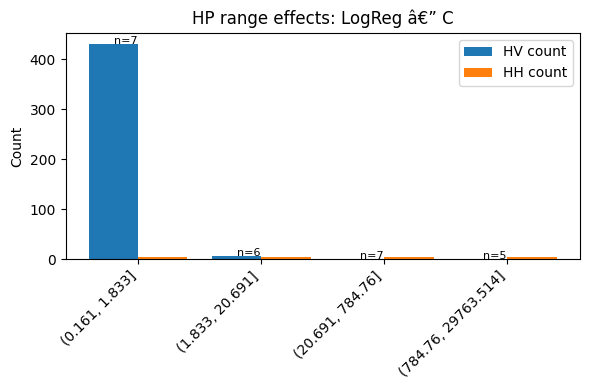

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\hp_range_effects_compas_LogReg_C.pdf


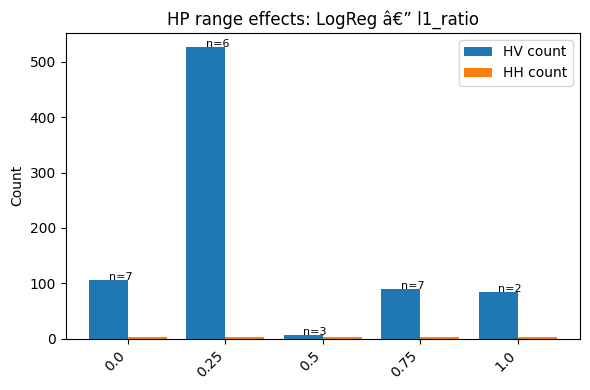

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\hp_range_effects_compas_LogReg_l1_ratio.pdf


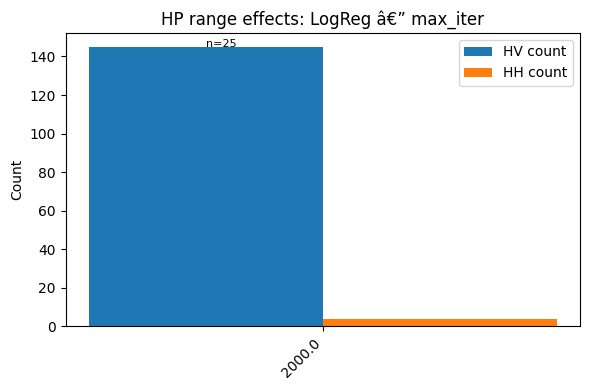

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\hp_range_effects_compas_LogReg_max_iter.pdf


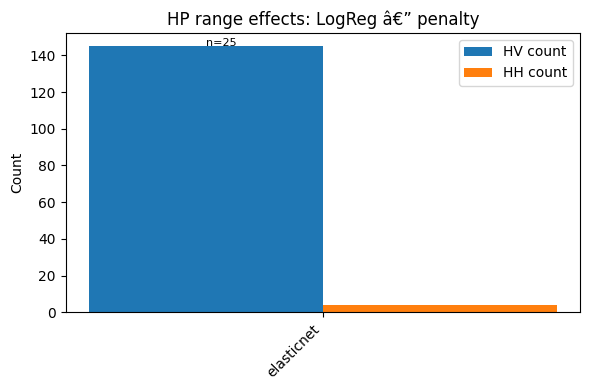

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\hp_range_effects_compas_LogReg_penalty.pdf


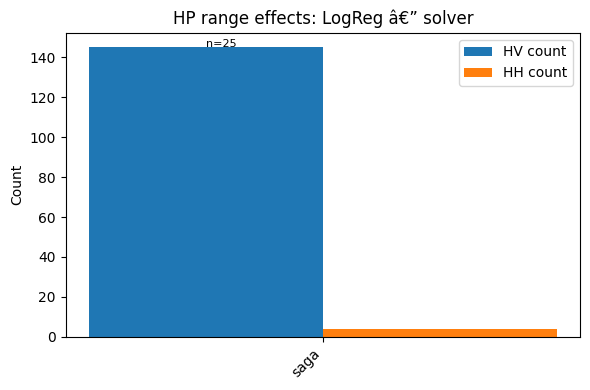

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\hp_range_effects_compas_LogReg_solver.pdf


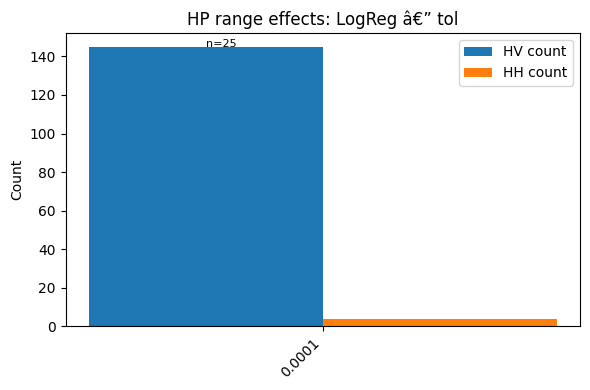

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\hp_range_effects_compas_LogReg_tol.pdf


c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\esda\moran.py:260: RuntimeWarning: invalid value encountered in scalar divide
  k = k_num / k_den
c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\esda\moran.py:272: RuntimeWarning: invalid value encountered in scalar divide
  return self.n / s0 * inum / self.z2ss
c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\esda\moran.py:229: RuntimeWarning: invalid value encountered in divide
  self.z /= sy


Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\tables\hp_range_effects_compas_kNN.csv


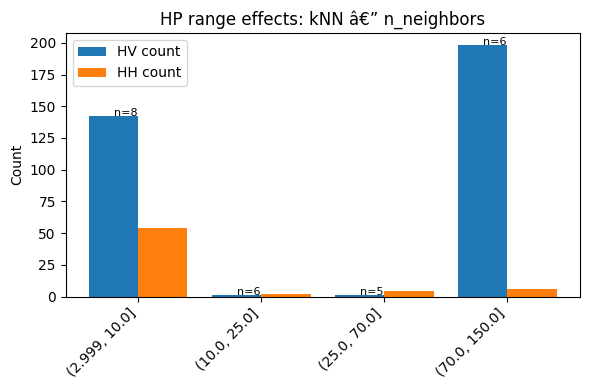

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\hp_range_effects_compas_kNN_n_neighbors.pdf


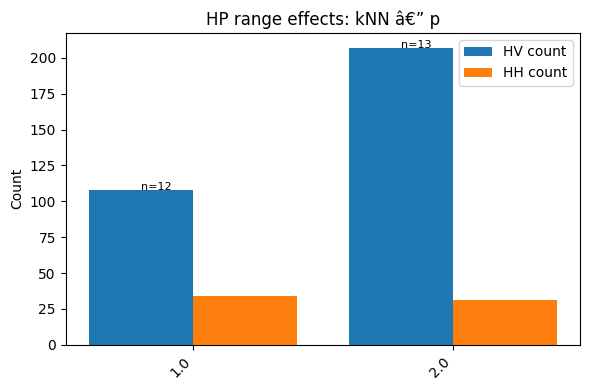

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\hp_range_effects_compas_kNN_p.pdf


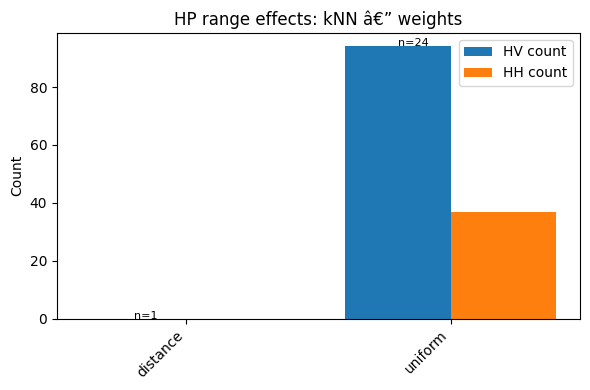

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\hp_range_effects_compas_kNN_weights.pdf
Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\tables\hp_range_effects_compas_RF.csv


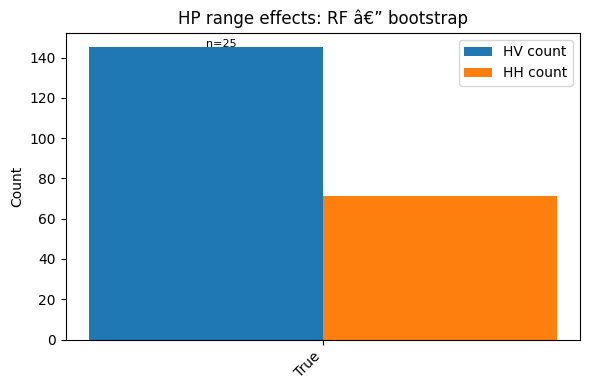

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\hp_range_effects_compas_RF_bootstrap.pdf


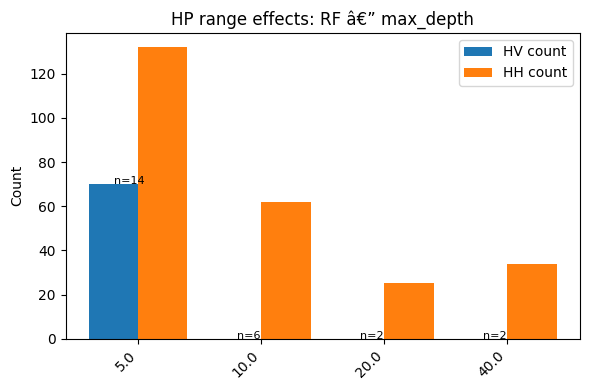

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\hp_range_effects_compas_RF_max_depth.pdf


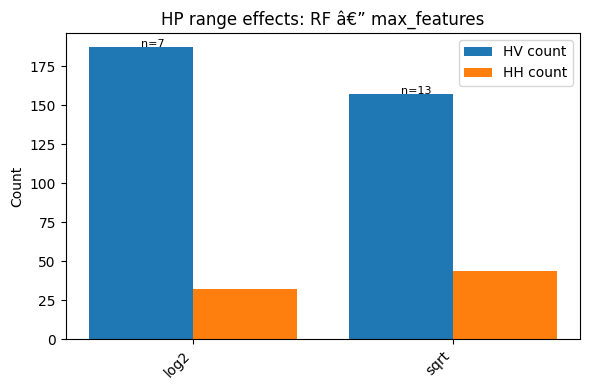

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\hp_range_effects_compas_RF_max_features.pdf


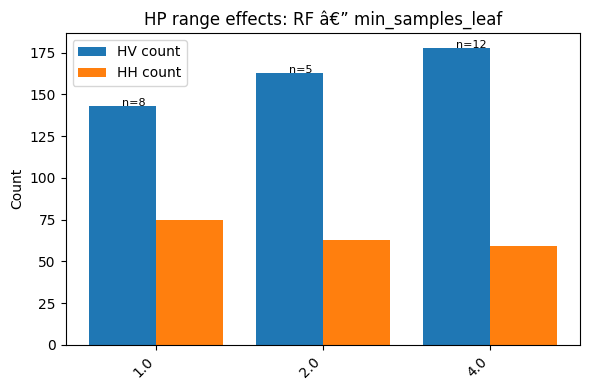

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\hp_range_effects_compas_RF_min_samples_leaf.pdf


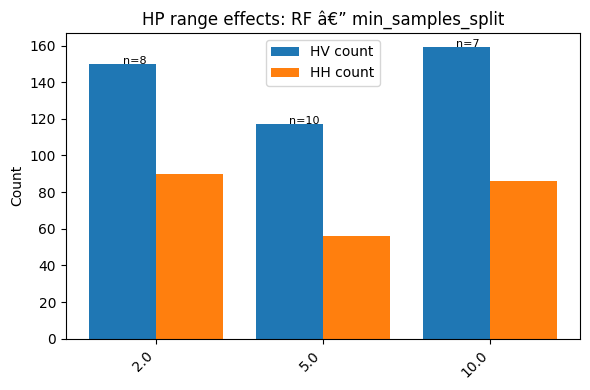

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\hp_range_effects_compas_RF_min_samples_split.pdf


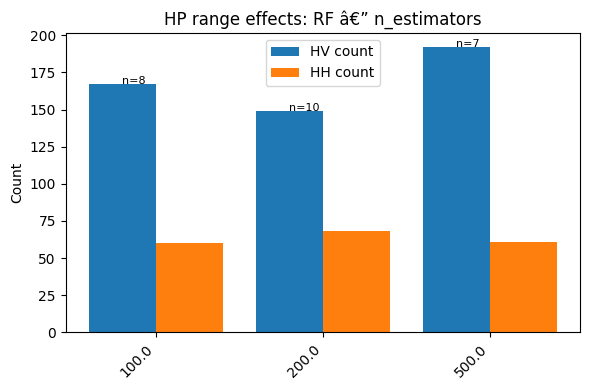

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\hp_range_effects_compas_RF_n_estimators.pdf


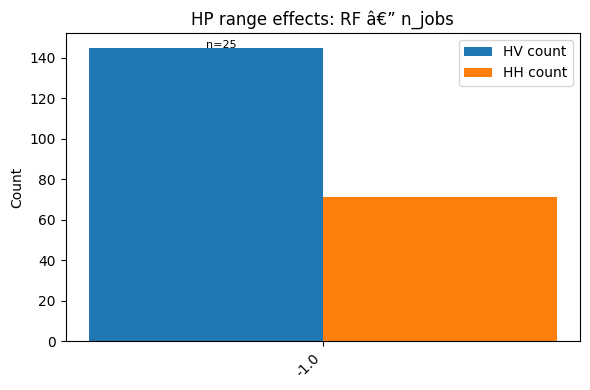

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\hp_range_effects_compas_RF_n_jobs.pdf
Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\tables\hp_range_effects_compas_GBM.csv


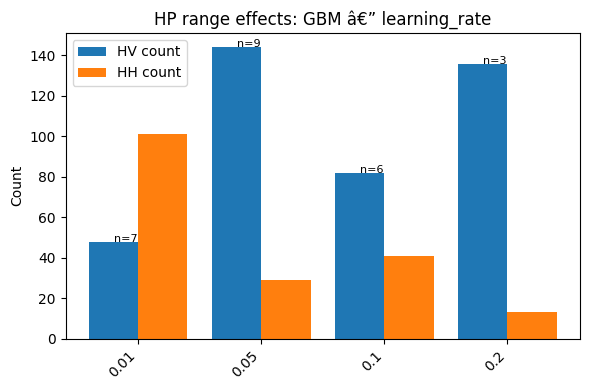

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\hp_range_effects_compas_GBM_learning_rate.pdf


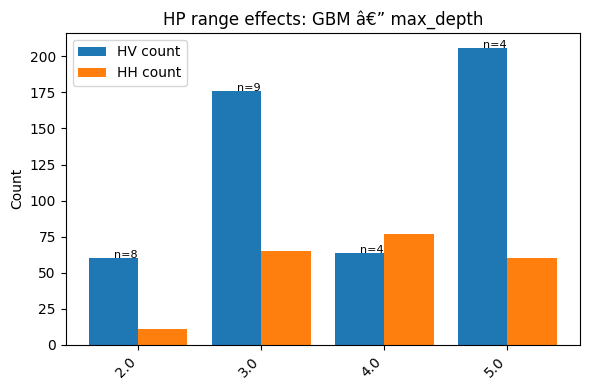

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\hp_range_effects_compas_GBM_max_depth.pdf


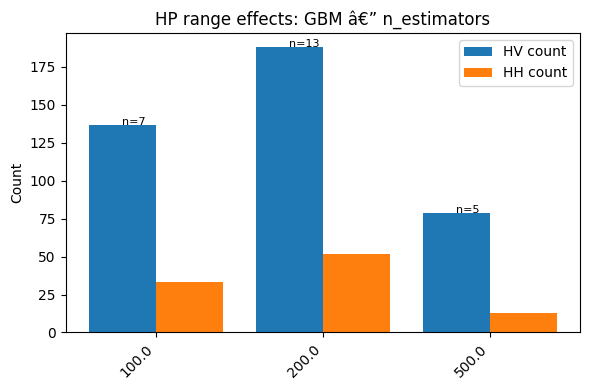

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\hp_range_effects_compas_GBM_n_estimators.pdf


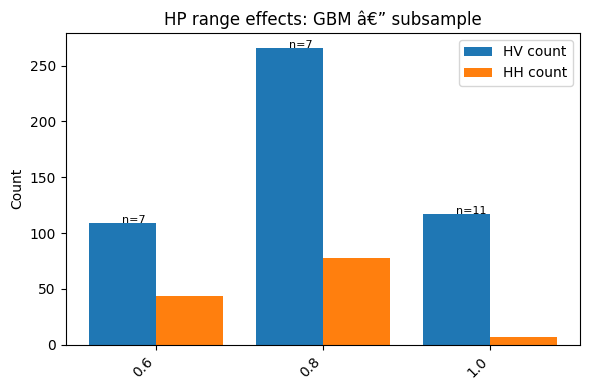

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\hp_range_effects_compas_GBM_subsample.pdf
Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\tables\hp_range_effects_compas_MLP.csv


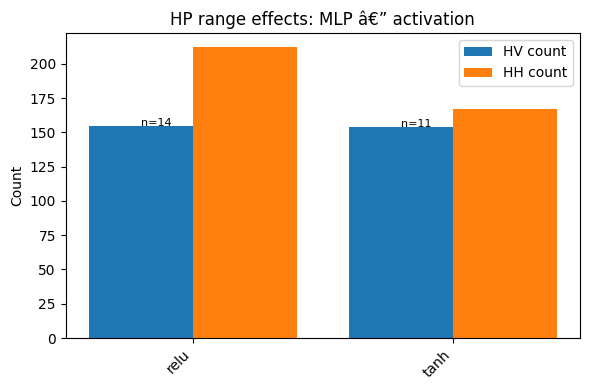

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\hp_range_effects_compas_MLP_activation.pdf


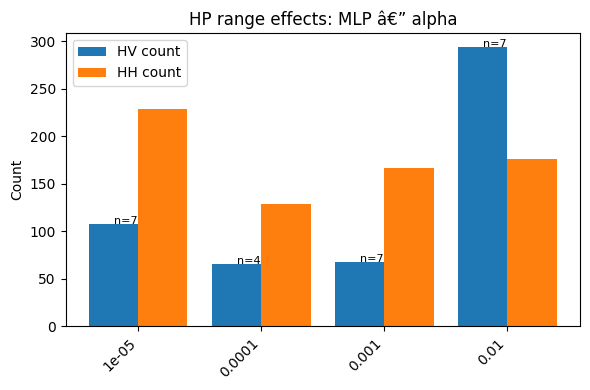

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\hp_range_effects_compas_MLP_alpha.pdf


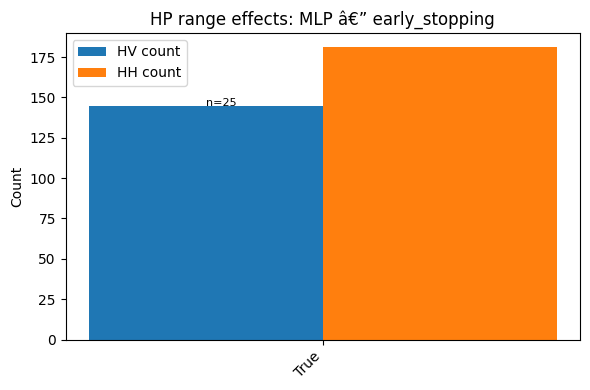

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\hp_range_effects_compas_MLP_early_stopping.pdf


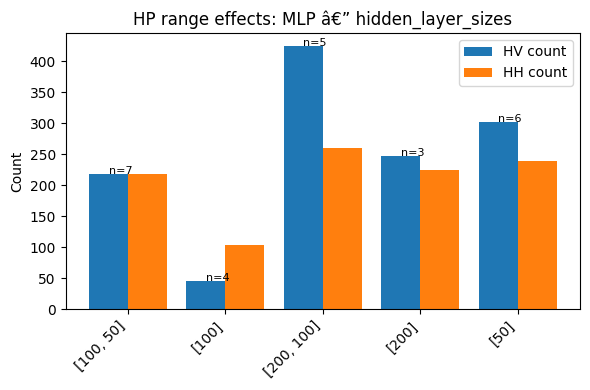

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\hp_range_effects_compas_MLP_hidden_layer_sizes.pdf


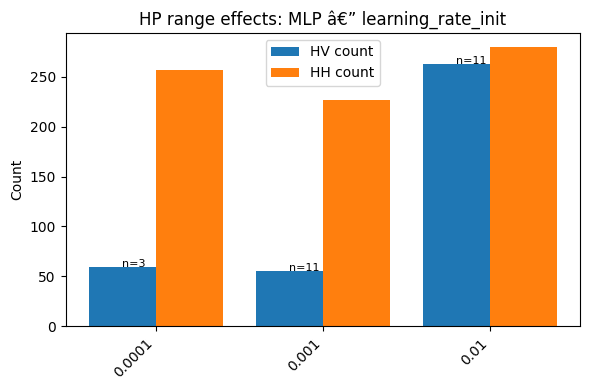

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\hp_range_effects_compas_MLP_learning_rate_init.pdf


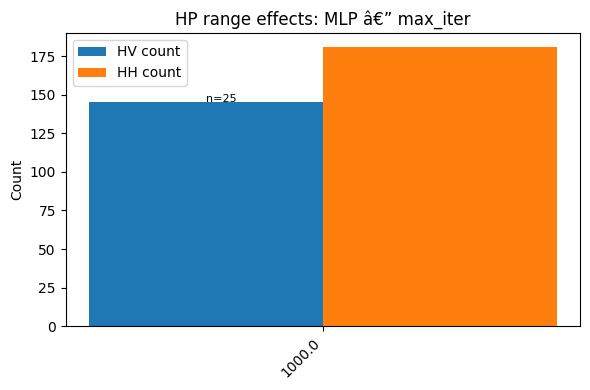

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\hp_range_effects_compas_MLP_max_iter.pdf


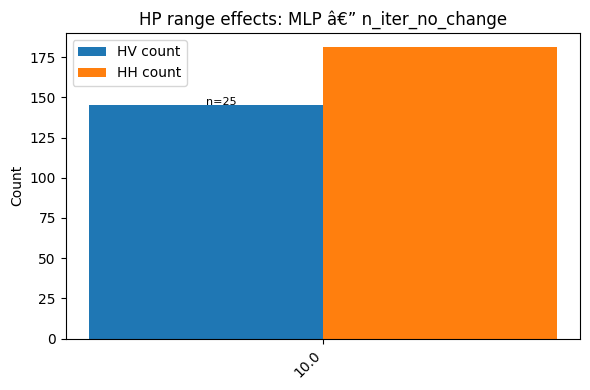

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\hp_range_effects_compas_MLP_n_iter_no_change.pdf


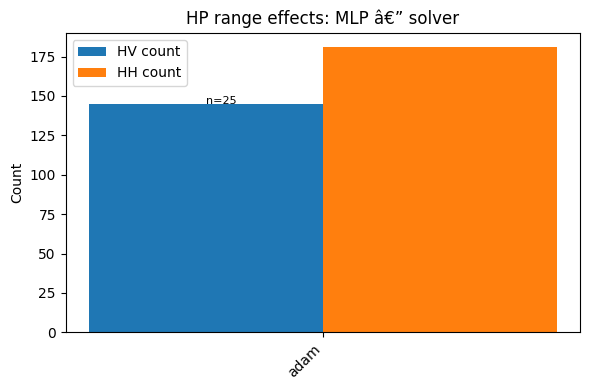

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\hp_range_effects_compas_MLP_solver.pdf


In [15]:
# Within-family HP range effects: option (A) family-level HV threshold
hp_cols_list = [c for c in meta.columns if c.startswith("hp_")]
N_QUANTILE_BINS = 4

for family in meta["model_name"].unique():
    meta_f = meta[meta["model_name"] == family].copy()
    top_idx = meta_f.nsmallest(min(top_k, len(meta_f)), loss_col).index.tolist()
    P_f = P[top_idx]
    meta_f = meta.loc[top_idx].copy()  # align by row with P_f
    var_f = np.var(P_f, axis=0, ddof=1)
    thresh_hv_f = np.percentile(var_f, 100 - q)  # family-level HV threshold (option A)

    hp_range_rows = []
    for hp_name in hp_cols_list:
        if hp_name not in meta_f.columns:
            continue
        col = meta_f[hp_name]
        # Convert unhashable types (list, dict) to string so nunique/groupby work
        if col.apply(lambda x: isinstance(x, (list, dict))).any():
            col = col.astype(str)
        try:
            n_unique = col.nunique()
        except TypeError:
            col = col.astype(str)
            n_unique = col.nunique()
        if pd.api.types.is_numeric_dtype(col) and n_unique > 5:
            try:
                bin_col = pd.qcut(col, q=min(N_QUANTILE_BINS, n_unique), duplicates="drop")
            except Exception:
                bin_col = col
            groups = meta_f.groupby(bin_col, observed=True)
        else:
            groups = meta_f.groupby(col, observed=True)

        for grp_label, grp_df in groups:
            iloc_mask = grp_df.index.isin(meta_f.index)
            loc_pos = np.where(meta_f.index.isin(grp_df.index))[0]
            P_fg = P_f[loc_pos]
            n_g = len(loc_pos)
            if n_g < 2:
                var_fg = np.zeros_like(var_f)
            else:
                var_fg = np.var(P_fg, axis=0, ddof=1)
            hv_count_fg = int(np.sum(var_fg >= thresh_hv_f))
            res_g = spatial_analysis(var_fg, X_test_numeric, k=knn_k)
            hh_count_fg = int(np.sum(res_g["HH_mask"]))
            overlap_fg = int(np.sum((var_fg >= thresh_hv_f) & res_g["HH_mask"]))
            mean_var_fg = float(np.mean(var_fg))
            if isinstance(grp_label, pd.Interval):
                hp_min, hp_max = grp_label.left, grp_label.right
            else:
                hp_min = hp_max = grp_label
            hp_range_rows.append({
                "family": family,
                "hp_name": hp_name.replace("hp_", ""),
                "group_label": str(grp_label),
                "hp_value_min": hp_min,
                "hp_value_max": hp_max,
                "n_models_in_group": n_g,
                "hv_count": hv_count_fg,
                "hh_count": hh_count_fg,
                "overlap_count": overlap_fg,
                "mean_var": mean_var_fg,
            })

    if not hp_range_rows:
        continue
    df_hp = pd.DataFrame(hp_range_rows)
    out_csv = TABLES_DIR / f"hp_range_effects_{dataset_name}_{family}.csv"
    df_hp.to_csv(out_csv, index=False)
    print(f"Saved: {out_csv}")

    # Plot per HP: x = group_label, y = hv_count and hh_count, annotate n_models
    for hp_name in df_hp["hp_name"].unique():
        sub = df_hp[df_hp["hp_name"] == hp_name]
        if len(sub) == 0:
            continue
        fig, ax = plt.subplots(figsize=(max(6, len(sub) * 0.8), 4))
        x_pos = np.arange(len(sub))
        ax.bar(x_pos - 0.2, sub["hv_count"], 0.4, label="HV count")
        ax.bar(x_pos + 0.2, sub["hh_count"], 0.4, label="HH count")
        ax.set_xticks(x_pos)
        ax.set_xticklabels([str(s)[:20] for s in sub["group_label"]], rotation=45, ha="right")
        for i in range(len(sub)):
            r = sub.iloc[i]
            ax.annotate(f"n={int(r['n_models_in_group'])}", (i - 0.2, r["hv_count"]), fontsize=8)
        ax.set_ylabel("Count")
        ax.set_title(f"HP range effects: {family} â€” {hp_name}")
        ax.legend()
        plt.tight_layout()
        fig_path = FIGURES_DIR / f"hp_range_effects_{dataset_name}_{family}_{hp_name}.pdf"
        plt.savefig(fig_path)
        plt.show()
        print(f"Saved: {fig_path}")

## 6. Per-family HP importance (top 3) and variance decomposition

**Per-family key HPs:** For each family we use its **family-specific Rashomon set** (top 25 by loss) and compute within-family hyperparameter importance via `compute_within_family_hp_importance(meta_f, P_f)`. We then restrict variance decomposition and profiling to the **top 3 HPs** for that family (no global key HPs across families).

A) Family-level importance (Rashomon subset, top_k per family):
 n_models_total  n_groups  mean_ratio  ratio_of_sums  median_ratio  p90_ratio
            125         5    0.335971       0.388554      0.323766   0.592339


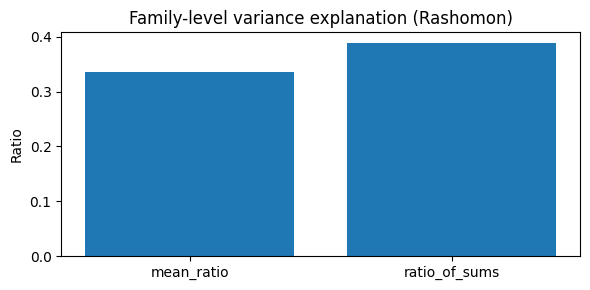


B) Within-family hyperparameter importance (top 3 per family for downstream analysis):

  Family: GBM â€” top 3 HPs: ['learning_rate', 'max_depth', 'subsample']
           hp  n_models_used  n_groups  ratio_of_sums  mean_ratio
learning_rate             25         4       0.337331    0.332212
    max_depth             25         4       0.258144    0.272210
    subsample             25         3       0.088820    0.105786

  Family: LogReg â€” top 3 HPs: ['C', 'l1_ratio']
      hp  n_models_used  n_groups  ratio_of_sums  mean_ratio
       C             25        10       0.864779    0.768284
l1_ratio             25         5       0.049767    0.093918

  Family: MLP â€” top 3 HPs: ['alpha', 'learning_rate_init', 'hidden_layer_sizes']
                hp  n_models_used  n_groups  ratio_of_sums  mean_ratio
             alpha             25         4       0.250357    0.236809
learning_rate_init             25         3       0.188544    0.141207
hidden_layer_sizes             25         5

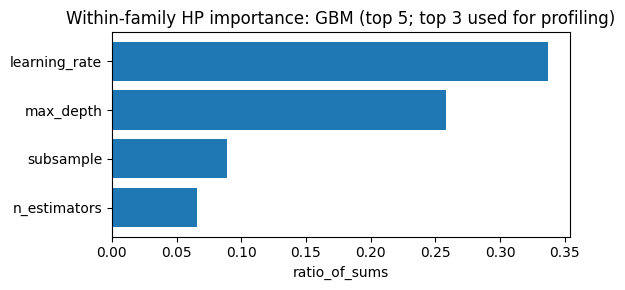

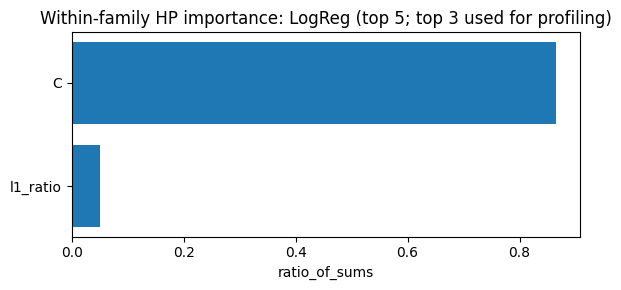

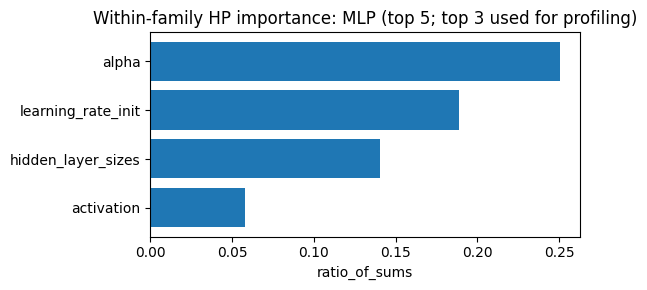

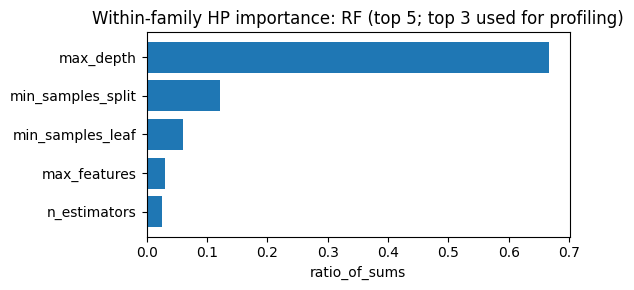

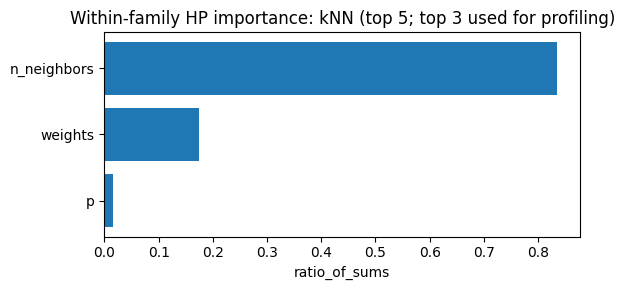

In [16]:
# Use family-specific Rashomon sets (top_k per family by loss) for HP importance
rashomon_idx = []
for family in meta["model_name"].unique():
    meta_f = meta[meta["model_name"] == family]
    top_idx = meta_f.nsmallest(min(top_k, len(meta_f)), loss_col).index.tolist()
    rashomon_idx.extend(top_idx)
meta_rashomon = meta.loc[rashomon_idx].copy()
P_rashomon = P[rashomon_idx]

# --- A) Family-level importance on Rashomon subset ---
family_imp = compute_family_importance(meta_rashomon, P_rashomon, family_col="model_name")
print("A) Family-level importance (Rashomon subset, top_k per family):")
print(family_imp[["n_models_total", "n_groups", "mean_ratio", "ratio_of_sums", "median_ratio", "p90_ratio"]].to_string(index=False))
plt.figure(figsize=(6, 3))
plt.bar(["mean_ratio", "ratio_of_sums"], [family_imp["mean_ratio"].iloc[0], family_imp["ratio_of_sums"].iloc[0]])
plt.ylabel("Ratio")
plt.title("Family-level variance explanation (Rashomon)")
plt.tight_layout()
plt.show()

# --- B) Within-family HP importance; top 3 HPs per family for profiling/range analysis ---
hp_col_names = [c.replace("hp_", "") for c in meta.columns if c.startswith("hp_")]
within_fam = compute_within_family_hp_importance(
    meta_rashomon, P_rashomon, hp_cols=hp_col_names, family_col="model_name", min_models_per_family=3
)
print("\nB) Within-family hyperparameter importance (top 3 per family for downstream analysis):")
TOP_HP_PER_FAMILY = 3
key_hps_per_family = {}
for fam in within_fam["family"].unique():
    df_f = within_fam[within_fam["family"] == fam].sort_values("ratio_of_sums", ascending=False)
    key_hps_per_family[fam] = df_f.head(TOP_HP_PER_FAMILY)["hp"].tolist()
    print(f"\n  Family: {fam} â€” top {TOP_HP_PER_FAMILY} HPs: {key_hps_per_family[fam]}")
    print(df_f[["hp", "n_models_used", "n_groups", "ratio_of_sums", "mean_ratio"]].head(TOP_HP_PER_FAMILY).to_string(index=False))
# Backward compatibility: union of all per-family top HPs for any downstream cell that uses key_hps
key_hps = sorted(set().union(*[set(key_hps_per_family[f]) for f in key_hps_per_family]))

# Bar plot per family (top 5 for display)
for fam in within_fam["family"].unique():
    df_f = within_fam[within_fam["family"] == fam].head(5)
    if len(df_f) == 0:
        continue
    plt.figure(figsize=(6, 3))
    plt.barh(range(len(df_f)), df_f["ratio_of_sums"])
    plt.yticks(range(len(df_f)), df_f["hp"])
    plt.xlabel("ratio_of_sums")
    plt.title(f"Within-family HP importance: {fam} (top 5; top 3 used for profiling)")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

## 5. Variance Decomposition by Model Family (within-family detail)

Analyze hyperparameter effects separately for each model family. This is the within-family detailed breakdown (same hierarchy as Section 4B).


Family: LogReg
hyperparameter  mean_var_between_ratio  ratio_of_sums  median_ratio  p90_ratio  mean_var_within_ratio  n_values  n_groups  n_models_total  n_models_used
             C                0.952808       0.989108      0.986622   0.992699               0.047192        20        20              50             50
      l1_ratio                0.054097       0.051085      0.052003   0.074038               0.945903         5         5              50             50


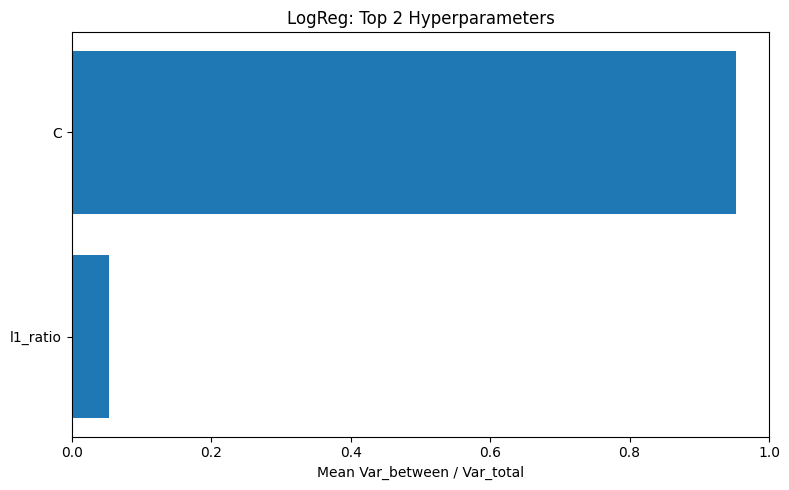


Family: kNN
hyperparameter  mean_var_between_ratio  ratio_of_sums  median_ratio  p90_ratio  mean_var_within_ratio  n_values  n_groups  n_models_total  n_models_used
       weights                0.377461       0.666548      0.238846   0.928039               0.622539         2         2              50             50
   n_neighbors                0.458415       0.244520      0.417838   0.921653               0.541585        13        13              50             50
             p                0.008903       0.003577      0.000471   0.018172               0.991097         2         2              50             50


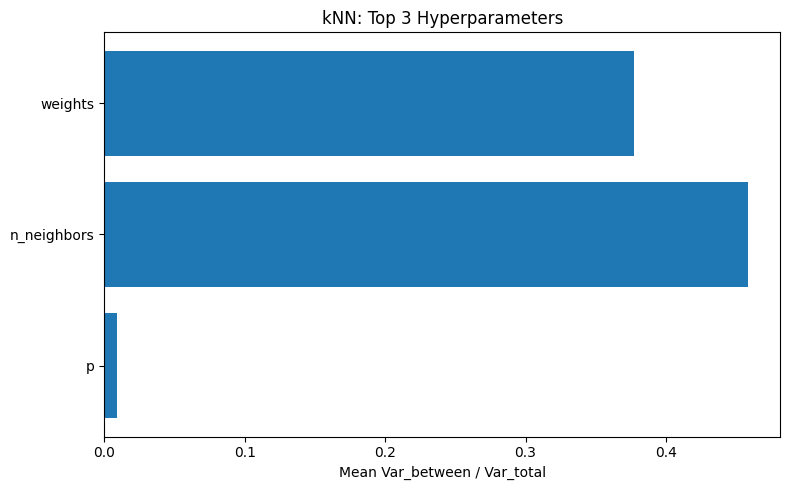


Family: RF
   hyperparameter  mean_var_between_ratio  ratio_of_sums  median_ratio  p90_ratio  mean_var_within_ratio  n_values  n_groups  n_models_total  n_models_used
        max_depth                0.527677       0.605788      0.550956   0.884437               0.472323         4         4              50             43
 min_samples_leaf                0.114832       0.136973      0.104957   0.210428               0.885168         3         3              50             50
min_samples_split                0.034861       0.035059      0.029362   0.069177               0.965139         3         3              50             50
     n_estimators                0.019035       0.018084      0.013569   0.044456               0.980965         3         3              50             50
     max_features                0.016617       0.015392      0.010080   0.041326               0.983383         2         2              50             36


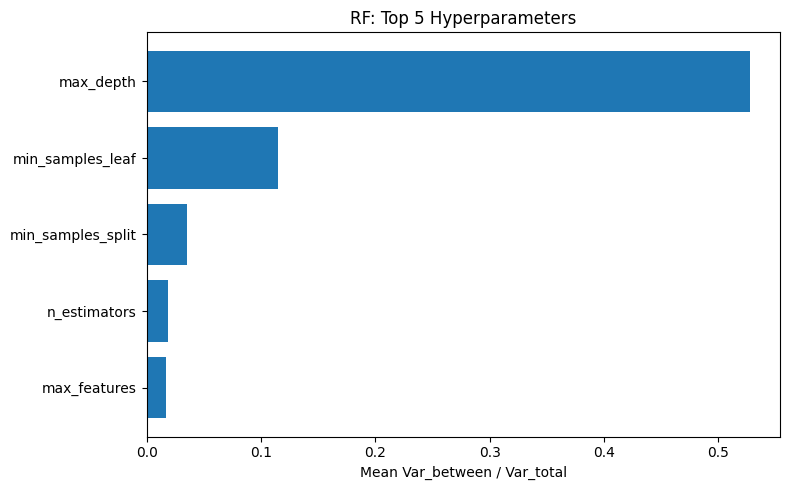


Family: GBM
hyperparameter  mean_var_between_ratio  ratio_of_sums  median_ratio  p90_ratio  mean_var_within_ratio  n_values  n_groups  n_models_total  n_models_used
 learning_rate                0.376933       0.412814      0.389348   0.652982               0.623067         4         4              50             50
  n_estimators                0.156755       0.168193      0.158279   0.259546               0.843245         3         3              50             50
     max_depth                0.142694       0.148534      0.117168   0.301647               0.857306         4         4              50             50
     subsample                0.057737       0.059270      0.051966   0.105942               0.942263         3         3              50             50


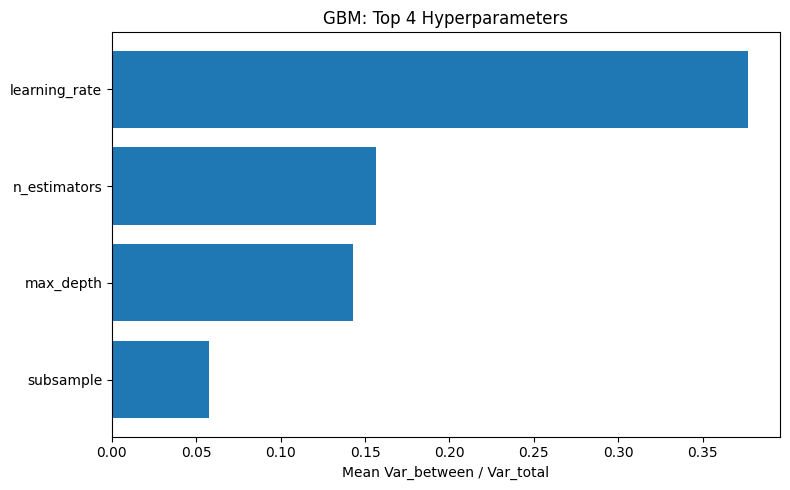


Family: MLP
    hyperparameter  mean_var_between_ratio  ratio_of_sums  median_ratio  p90_ratio  mean_var_within_ratio  n_values  n_groups  n_models_total  n_models_used
learning_rate_init                0.197038       0.225677      0.175754   0.400206               0.802962         3         3              50             50
hidden_layer_sizes                0.068608       0.071369      0.061517   0.128087               0.931392         5         5              50             50
        activation                0.058298       0.062087      0.019754   0.146371               0.941702         2         2              50             50
             alpha                0.056035       0.047755      0.044007   0.117674               0.943965         4         4              50             50


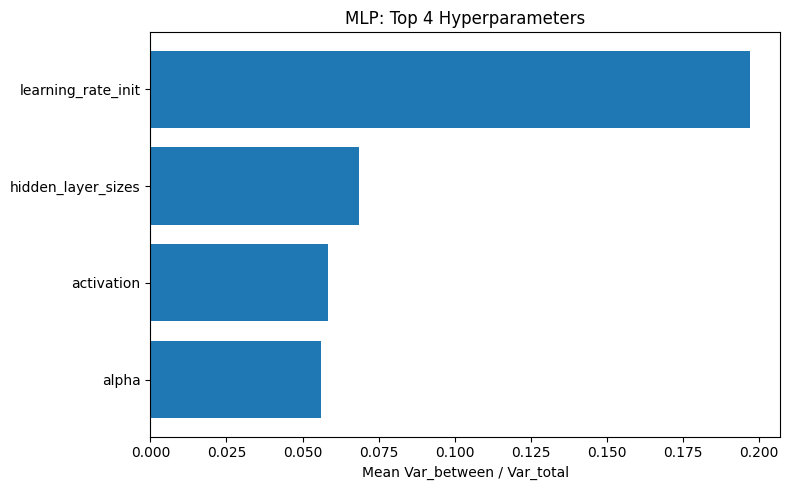

In [17]:
families = meta['model_name'].unique()

for family in families:
    print(f"\n{'='*60}")
    print(f"Family: {family}")
    print(f"{'='*60}")
    
    family_importance = compute_hp_importance(P, meta, model_family=family)
    
    if len(family_importance) > 0:
        print(family_importance.to_string(index=False))
        
        # Plot top hyperparameters for this family
        plt.figure(figsize=(8, 5))
        top_n = min(5, len(family_importance))
        top_hps = family_importance.head(top_n)
        plt.barh(range(len(top_hps)), top_hps['mean_var_between_ratio'])
        plt.yticks(range(len(top_hps)), top_hps['hyperparameter'])
        plt.xlabel('Mean Var_between / Var_total')
        plt.title(f'{family}: Top {top_n} Hyperparameters')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
    else:
        print("  No hyperparameters to analyze")

## 6. Detailed Variance Decomposition for Key Hyperparameters

For selected hyperparameters, show the full variance decomposition across observations.

Analyzing variance decomposition for top 3 HPs per family (Rashomon set).


Family: GBM (top 3 HPs: ['learning_rate', 'max_depth', 'subsample'])

  Hyperparameter: learning_rate
Unique values: 4
Model counts per value:
  0.05: 9 models
  0.01: 7 models
  0.1: 6 models
  0.2: 3 models

Variance decomposition (mean across observations):
  Var_total: 0.001033
  Var_between: 0.000348 (33.2%)
  Var_within: 0.000684 (66.8%)


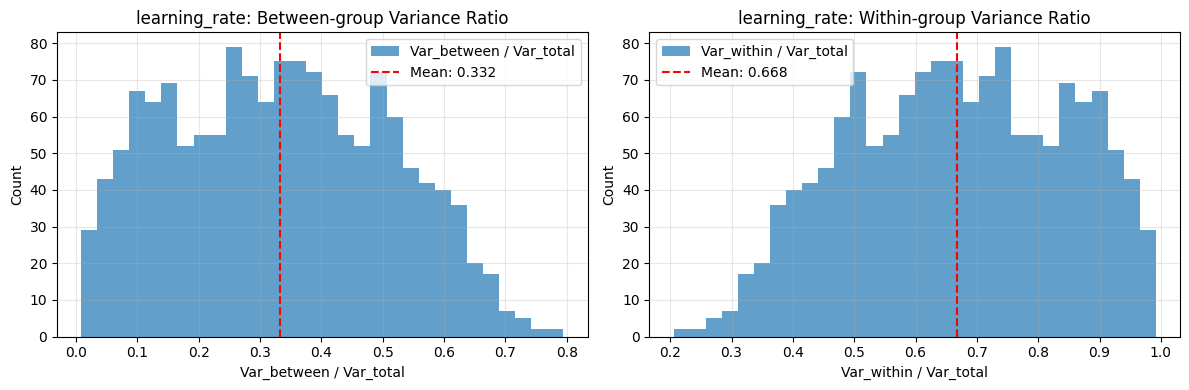


  Hyperparameter: max_depth
Unique values: 4
Model counts per value:
  3.0: 9 models
  2.0: 8 models
  4.0: 4 models
  5.0: 4 models

Variance decomposition (mean across observations):
  Var_total: 0.001033
  Var_between: 0.000267 (27.2%)
  Var_within: 0.000766 (72.8%)


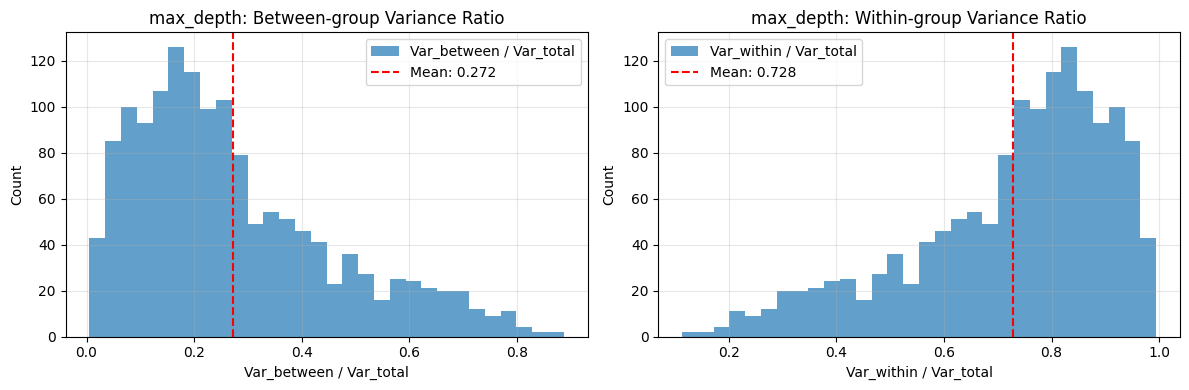


  Hyperparameter: subsample
Unique values: 3
Model counts per value:
  1.0: 11 models
  0.6: 7 models
  0.8: 7 models

Variance decomposition (mean across observations):
  Var_total: 0.001033
  Var_between: 0.000092 (10.6%)
  Var_within: 0.000941 (89.4%)


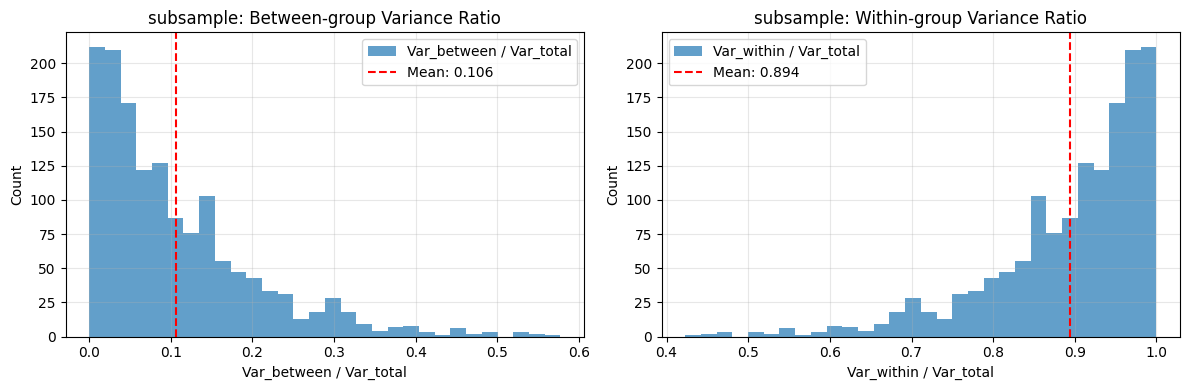


Family: LogReg (top 3 HPs: ['C', 'l1_ratio'])

  Hyperparameter: C
Unique values: 10
Model counts per value:
  20.6913808111479: 4 models
  1.8329807108324339: 3 models
  233.57214690901213: 3 models
  784.7599703514607: 3 models
  29763.51441631313: 3 models

Variance decomposition (mean across observations):
  Var_total: 0.000006
  Var_between: 0.000005 (76.8%)
  Var_within: 0.000001 (23.2%)


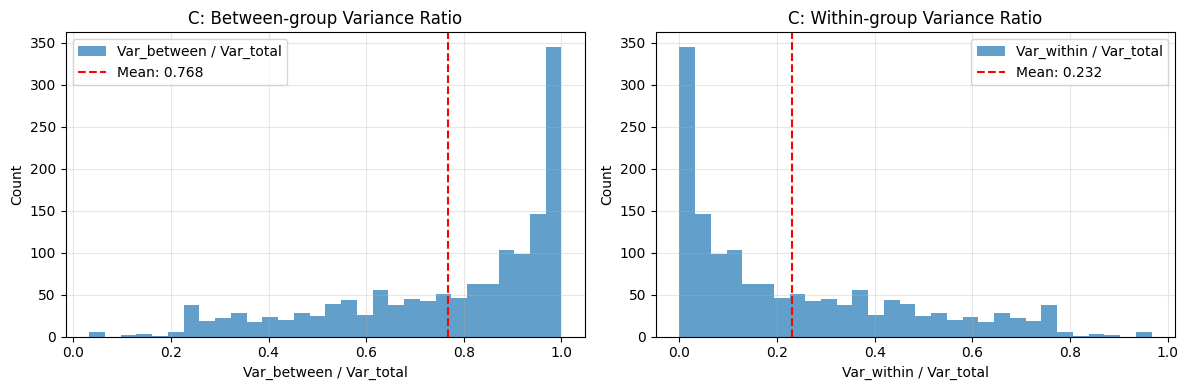


  Hyperparameter: l1_ratio
Unique values: 5
Model counts per value:
  0.0: 7 models
  0.75: 7 models
  0.25: 6 models
  0.5: 3 models
  1.0: 2 models

Variance decomposition (mean across observations):
  Var_total: 0.000006
  Var_between: 0.000000 (9.4%)
  Var_within: 0.000005 (90.6%)


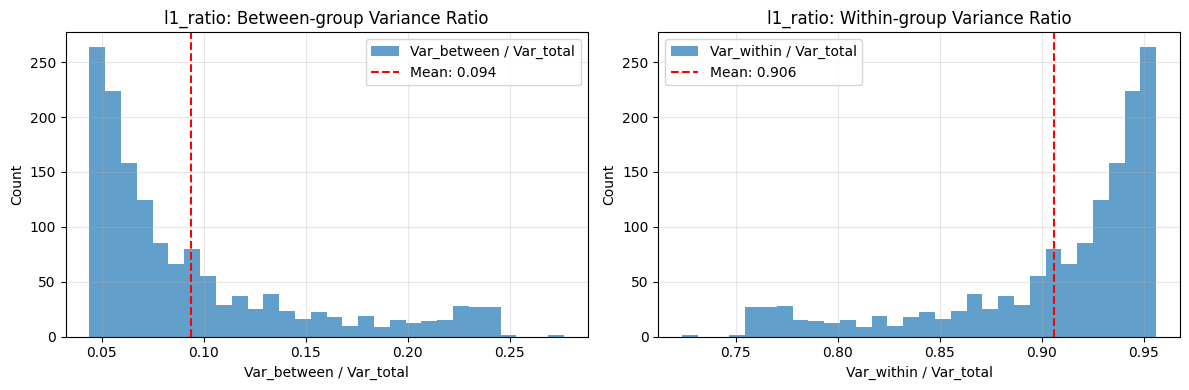


Family: MLP (top 3 HPs: ['alpha', 'learning_rate_init', 'hidden_layer_sizes'])

  Hyperparameter: alpha
Unique values: 4
Model counts per value:
  0.001: 7 models
  1e-05: 7 models
  0.01: 7 models
  0.0001: 4 models

Variance decomposition (mean across observations):
  Var_total: 0.001066
  Var_between: 0.000267 (23.7%)
  Var_within: 0.000799 (76.3%)


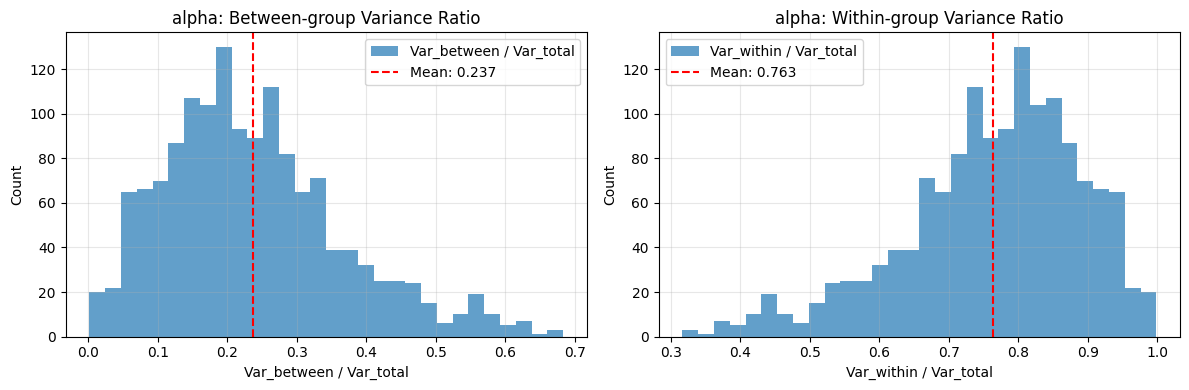


  Hyperparameter: learning_rate_init
Unique values: 3
Model counts per value:
  0.01: 11 models
  0.001: 11 models
  0.0001: 3 models

Variance decomposition (mean across observations):
  Var_total: 0.001066
  Var_between: 0.000201 (14.1%)
  Var_within: 0.000865 (85.9%)


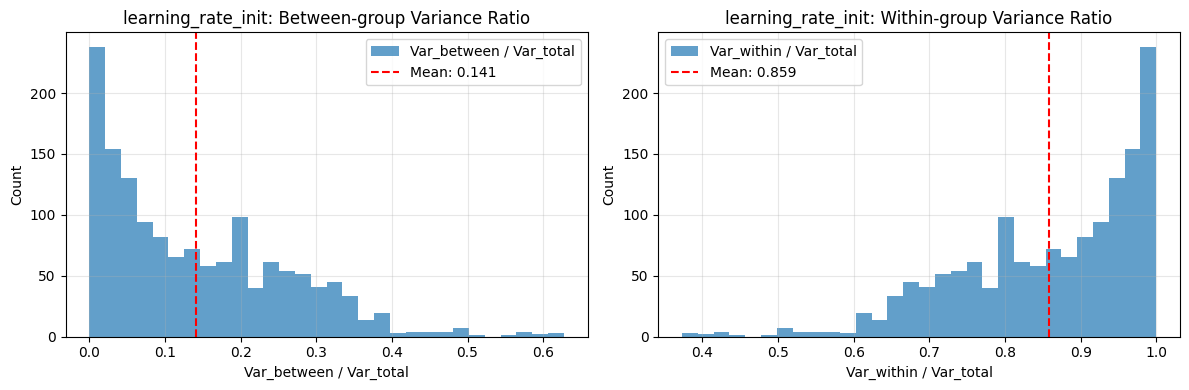


  Hyperparameter: hidden_layer_sizes
Unique values: 5
Model counts per value:
  (100, 50): 7 models
  (50,): 6 models
  (200, 100): 5 models
  (100,): 4 models
  (200,): 3 models

Variance decomposition (mean across observations):
  Var_total: 0.001066
  Var_between: 0.000150 (13.7%)
  Var_within: 0.000917 (86.3%)


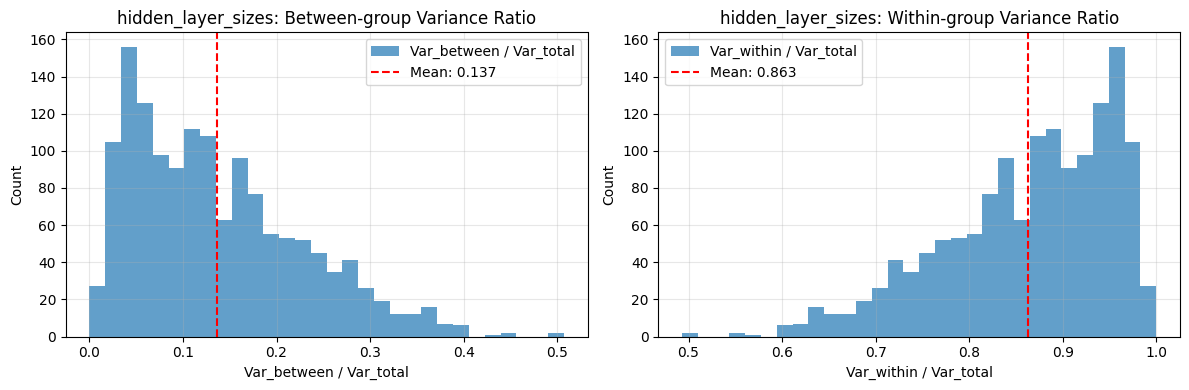


Family: RF (top 3 HPs: ['max_depth', 'min_samples_split', 'min_samples_leaf'])

  Hyperparameter: max_depth
Unique values: 5
Model counts per value:
  5.0: 14 models
  10.0: 6 models
  40.0: 2 models
  20.0: 2 models
  nan: 1 models

Variance decomposition (mean across observations):
  Var_total: 0.003053
  Var_between: 0.002086 (60.2%)
  Var_within: 0.000968 (39.8%)


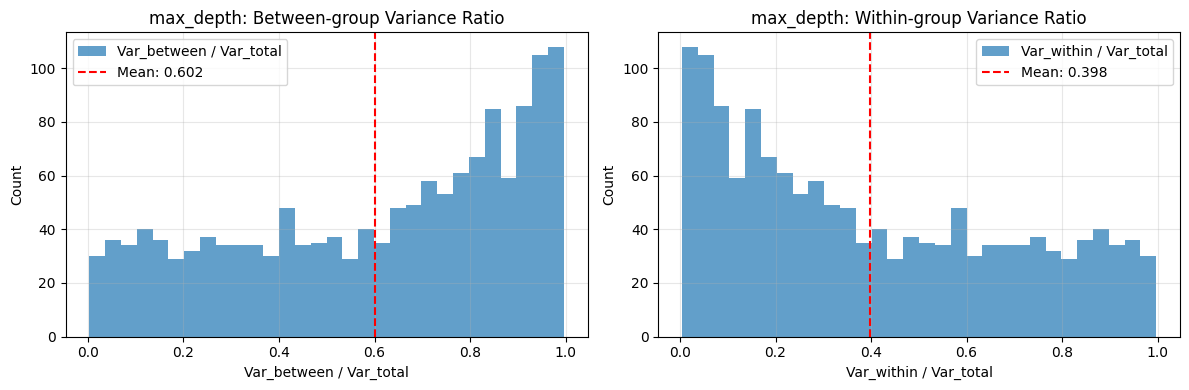


  Hyperparameter: min_samples_split
Unique values: 3
Model counts per value:
  5.0: 10 models
  2.0: 8 models
  10.0: 7 models

Variance decomposition (mean across observations):
  Var_total: 0.003053
  Var_between: 0.000372 (10.7%)
  Var_within: 0.002682 (89.3%)


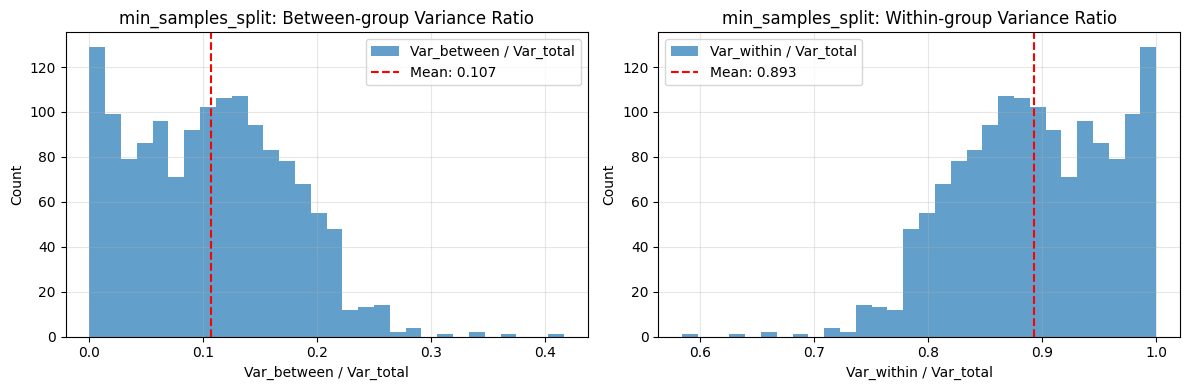


  Hyperparameter: min_samples_leaf
Unique values: 3
Model counts per value:
  4.0: 12 models
  1.0: 8 models
  2.0: 5 models

Variance decomposition (mean across observations):
  Var_total: 0.003053
  Var_between: 0.000185 (7.2%)
  Var_within: 0.002868 (92.8%)


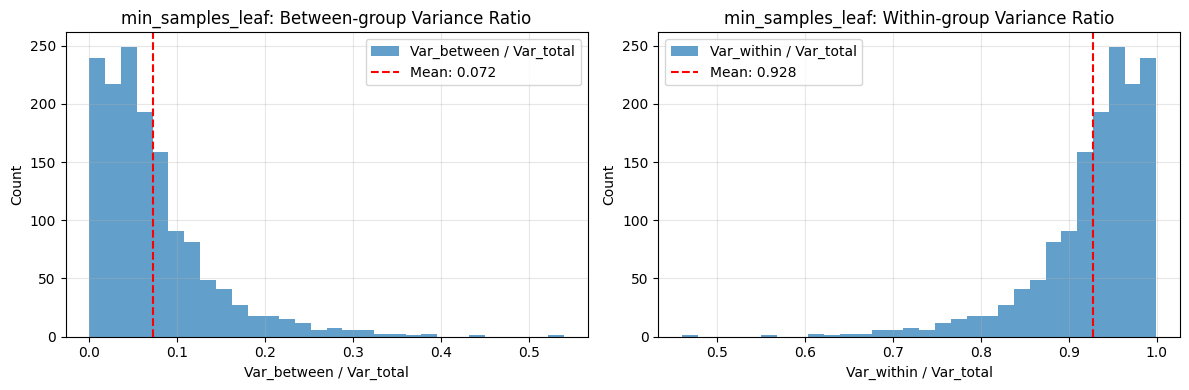


Family: kNN (top 3 HPs: ['n_neighbors', 'weights', 'p'])

  Hyperparameter: n_neighbors
Unique values: 13
Model counts per value:
  100.0: 2 models
  90.0: 2 models
  150.0: 2 models
  70.0: 2 models
  30.0: 2 models

Variance decomposition (mean across observations):
  Var_total: 0.011418
  Var_between: 0.009541 (83.6%)
  Var_within: 0.001877 (16.4%)


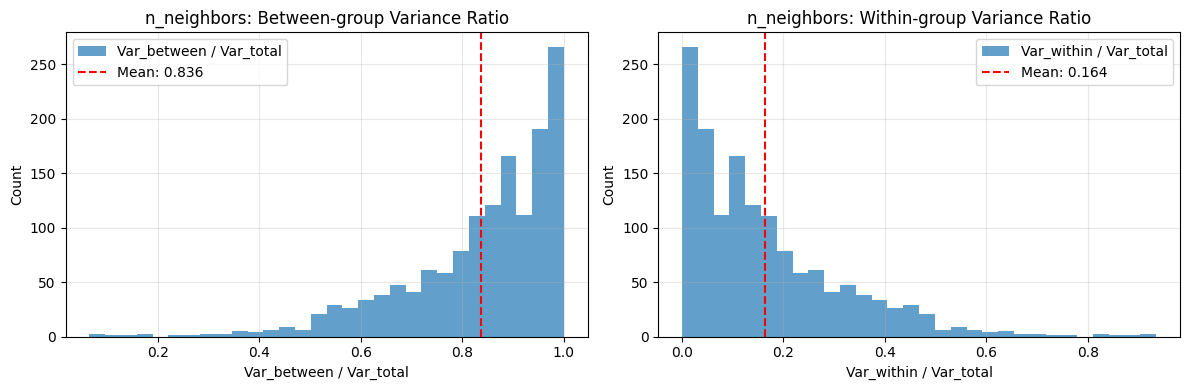


  Hyperparameter: weights
Unique values: 2
Model counts per value:
  uniform: 24 models
  distance: 1 models

Variance decomposition (mean across observations):
  Var_total: 0.011418
  Var_between: 0.002002 (13.9%)
  Var_within: 0.009416 (86.1%)


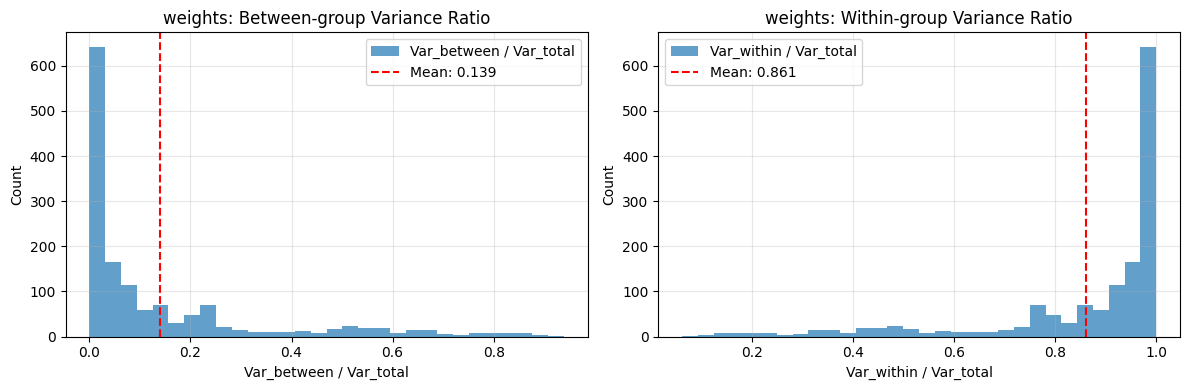


  Hyperparameter: p
Unique values: 2
Model counts per value:
  2.0: 13 models
  1.0: 12 models

Variance decomposition (mean across observations):
  Var_total: 0.011418
  Var_between: 0.000172 (1.6%)
  Var_within: 0.011246 (98.4%)


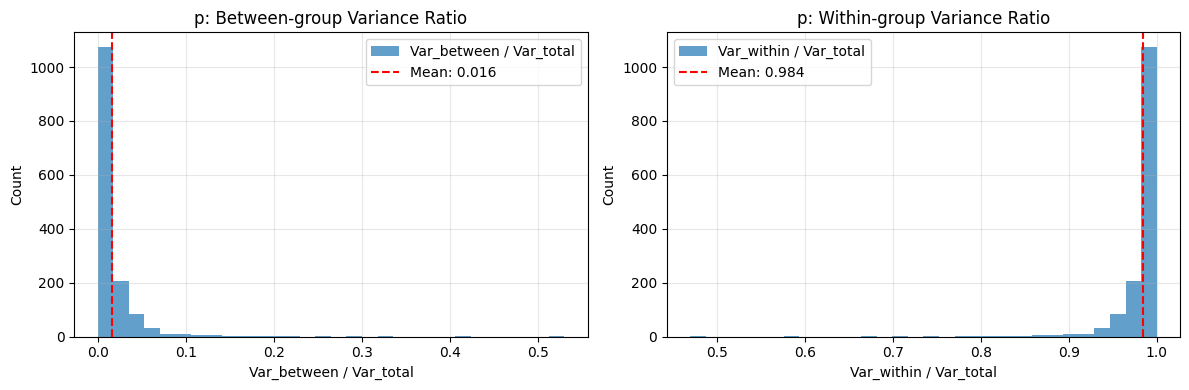

In [21]:
# Use per-family top 3 HPs and Rashomon sets (key_hps_per_family, meta_rashomon, P_rashomon from section 6)
print("Analyzing variance decomposition for top 3 HPs per family (Rashomon set).\n")

for fam in key_hps_per_family:
    key_hps_f = key_hps_per_family[fam]
    if not key_hps_f:
        continue
    mask_f = meta_rashomon["model_name"] == fam
    P_f = P_rashomon[mask_f]
    meta_f = meta_rashomon[mask_f]
    print(f"\n{'='*60}\nFamily: {fam} (top 3 HPs: {key_hps_f})\n{'='*60}")

    for hp_name in key_hps_f:
        print(f"\n  Hyperparameter: {hp_name}")
        try:
            decomp = variance_decomposition_by_hyperparameter(P_f, meta_f, hp_name)
            
            print(f"Unique values: {len(decomp['hp_values'])}")
            print(f"Model counts per value:")
            for hp_val, count in sorted(decomp['hp_counts'].items(), key=lambda x: x[1], reverse=True)[:5]:
                print(f"  {hp_val}: {count} models")
            
            # Summary statistics
            var_total = decomp['var_total']
            var_between = decomp['var_between']
            var_within = decomp['var_within']
            
            # Avoid division by zero
            mask = var_total > 1e-10
            if mask.sum() > 0:
                between_ratio = var_between[mask] / var_total[mask]
                within_ratio = var_within[mask] / var_total[mask]
                print(f"\nVariance decomposition (mean across observations):")
                print(f"  Var_total: {var_total[mask].mean():.6f}")
                print(f"  Var_between: {var_between[mask].mean():.6f} ({between_ratio.mean()*100:.1f}%)")
                print(f"  Var_within: {var_within[mask].mean():.6f} ({within_ratio.mean()*100:.1f}%)")
                # Plot distribution of ratios
                fig, axes = plt.subplots(1, 2, figsize=(12, 4))
                axes[0].hist(between_ratio, bins=30, alpha=0.7, label='Var_between / Var_total')
                axes[0].axvline(between_ratio.mean(), color='r', linestyle='--', label=f'Mean: {between_ratio.mean():.3f}')
                axes[0].set_xlabel('Var_between / Var_total')
                axes[0].set_ylabel('Count')
                axes[0].set_title(f'{hp_name}: Between-group Variance Ratio')
                axes[0].legend()
                axes[0].grid(True, alpha=0.3)
                axes[1].hist(within_ratio, bins=30, alpha=0.7, label='Var_within / Var_total')
                axes[1].axvline(within_ratio.mean(), color='r', linestyle='--', label=f'Mean: {within_ratio.mean():.3f}')
                axes[1].set_xlabel('Var_within / Var_total')
                axes[1].set_ylabel('Count')
                axes[1].set_title(f'{hp_name}: Within-group Variance Ratio')
                axes[1].legend()
                axes[1].grid(True, alpha=0.3)
                plt.tight_layout()
                plt.show()
            else:
                print("  Warning: All observations have near-zero variance")
        except Exception as e:
            print(f"  Error analyzing {hp_name}: {e}")


Using Îµ = 0.01 for local Rashomon sets


Hyperparameter Profiling: C
  [Sanity] C: 21 groups, 20 non-nan.

Local Rashomon sets for each C value:
              hp_value  best_loss  local_rashomon_size  total_models  local_rashomon_fraction
                   nan   0.206094                  129           200                    0.645
    0.1623776739188721   0.213836                    4             4                    1.000
    0.5455594781168515   0.213857                    2             2                    1.000
    1.8329807108324339   0.213879                    3             3                    1.000
    6.1584821106602545   0.213902                    2             2                    1.000
      20.6913808111479   0.213906                    4             4                    1.000
     69.51927961775606   0.213908                    1             1                    1.000
    233.57214690901213   0.213909                    3             3                    1.000
     784

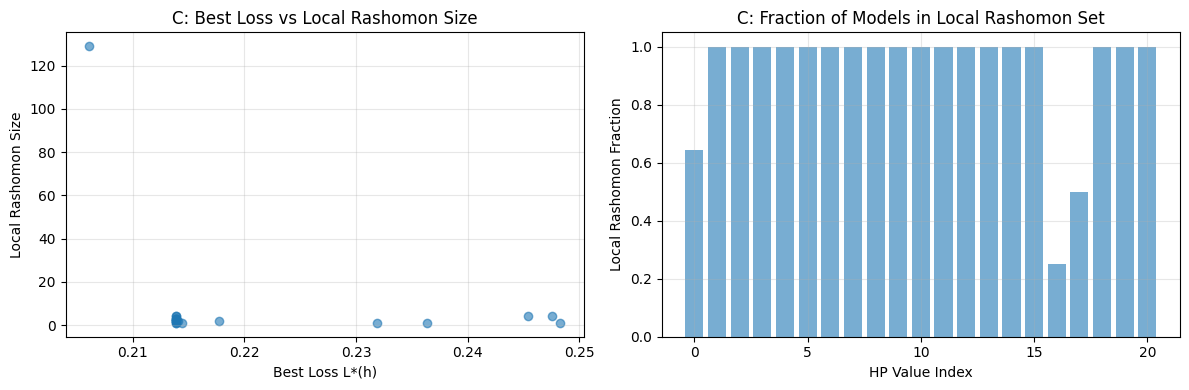


Hyperparameter Profiling: alpha
  [Sanity] alpha: 5 groups, 4 non-nan.

Local Rashomon sets for each alpha value:
hp_value  best_loss  local_rashomon_size  total_models  local_rashomon_fraction
     nan   0.206094                  116           200                 0.580000
  0.0001   0.207838                    9            10                 0.900000
   0.001   0.209441                   13            13                 1.000000
   1e-05   0.210074                   14            14                 1.000000
    0.01   0.210104                   12            13                 0.923077


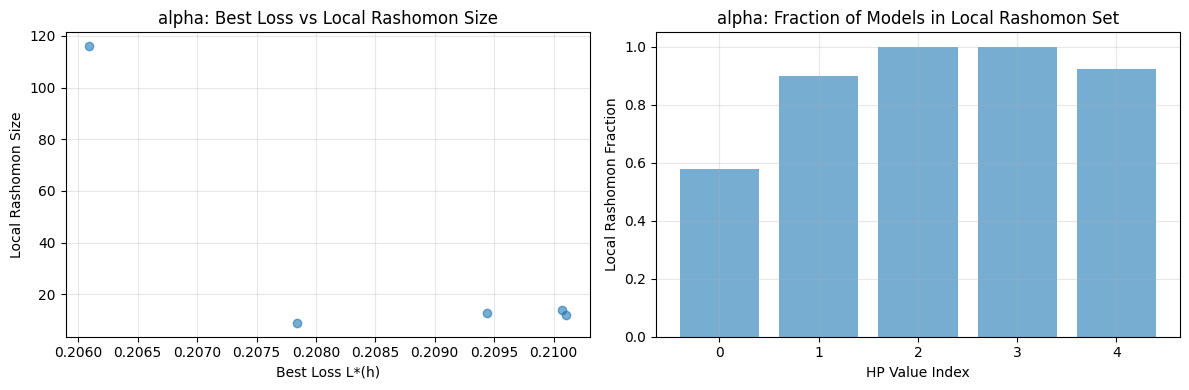

In [22]:
# Load epsilon from config
import json
with open(BASE_PATH / "config.json", "r") as f:
    config = json.load(f)
epsilon = config.get("epsilon", 0.01)

print(f"Using Îµ = {epsilon} for local Rashomon sets\n")

# Profile top hyperparameters
for hp_name in key_hps[:2]:  # Analyze top 2 for brevity
    print(f"\n{'='*60}")
    print(f"Hyperparameter Profiling: {hp_name}")
    print(f"{'='*60}")
    
    try:
        profile = hyperparameter_profiling(meta, hp_name, epsilon)
        n_non_nan = (profile["hp_value"].astype(str) != "nan").sum()
        print(f"  [Sanity] {hp_name}: {len(profile)} groups, {n_non_nan} non-nan.")
        if hp_name in ["max_depth", "n_estimators", "C", "max_iter"]:
            assert n_non_nan > 1, f"Expected >1 non-nan group for numeric HP {hp_name} (got {n_non_nan})"
        
        print(f"\nLocal Rashomon sets for each {hp_name} value:")
        print(profile.to_string(index=False))
        
        # Visualize
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        
        # Best loss vs local Rashomon size
        axes[0].scatter(profile['best_loss'], profile['local_rashomon_size'], alpha=0.6)
        axes[0].set_xlabel('Best Loss L*(h)')
        axes[0].set_ylabel('Local Rashomon Size')
        axes[0].set_title(f'{hp_name}: Best Loss vs Local Rashomon Size')
        axes[0].grid(True, alpha=0.3)
        
        # Local Rashomon fraction
        axes[1].bar(range(len(profile)), profile['local_rashomon_fraction'], alpha=0.6)
        axes[1].set_xlabel('HP Value Index')
        axes[1].set_ylabel('Local Rashomon Fraction')
        axes[1].set_title(f'{hp_name}: Fraction of Models in Local Rashomon Set')
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"  Error profiling {hp_name}: {e}")

## 8. Hyperparameter Effects on Hotspot Regions

Analyze whether certain hyperparameter values are associated with high-variance (hotspot) regions.

Hotspot (HH) observations: 10 / 1443 (0.7%)


C: Distribution in Hotspots vs Non-Hotspots

Mean contribution to hotspot variance by C value:
                            mean           std  count
hp_value                                             
3.359818286283781e-05   0.087431  6.270311e-03      4
1e-05                   0.087390  6.830380e-03      4
0.000379269019073225    0.070817  1.963532e-02      4
0.00011288378916846884  0.069789           NaN      1
0.0012742749857031334   0.068544  2.341631e-02      2
nan                     0.020163  2.818757e-02    200
29763.51441631313       0.011325  8.170383e-09      3
8858.667904100832       0.011325           NaN      1
100000.0                0.011325  8.574711e-09      2
2636.6508987303555      0.011325  2.185440e-09      2


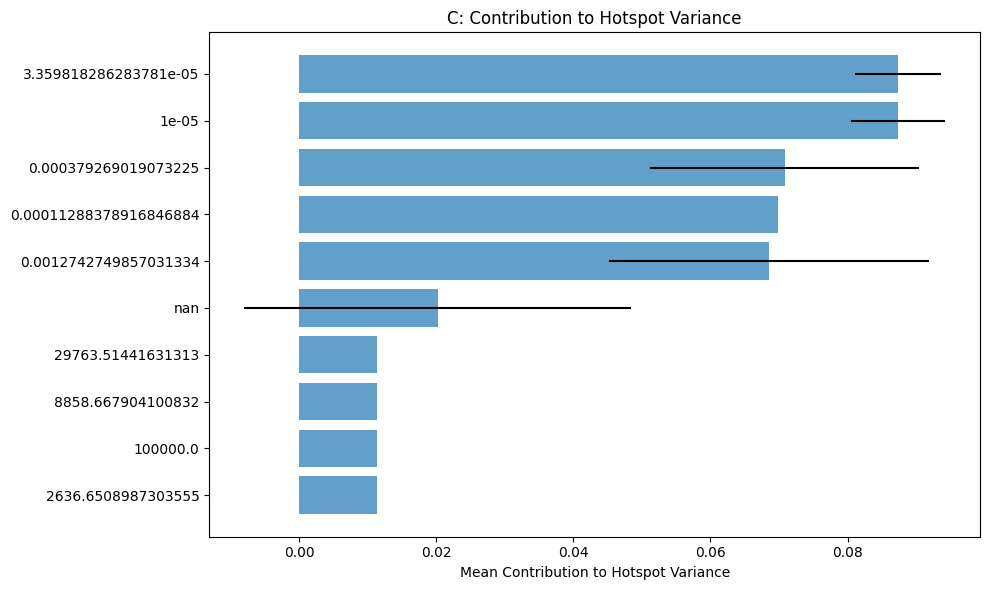


alpha: Distribution in Hotspots vs Non-Hotspots

Mean contribution to hotspot variance by alpha value:
              mean       std  count
hp_value                           
nan       0.025755  0.032001    200
1e-05     0.009334  0.002840     14
0.0001    0.009230  0.003601     10
0.01      0.008696  0.003186     13
0.001     0.008651  0.003377     13


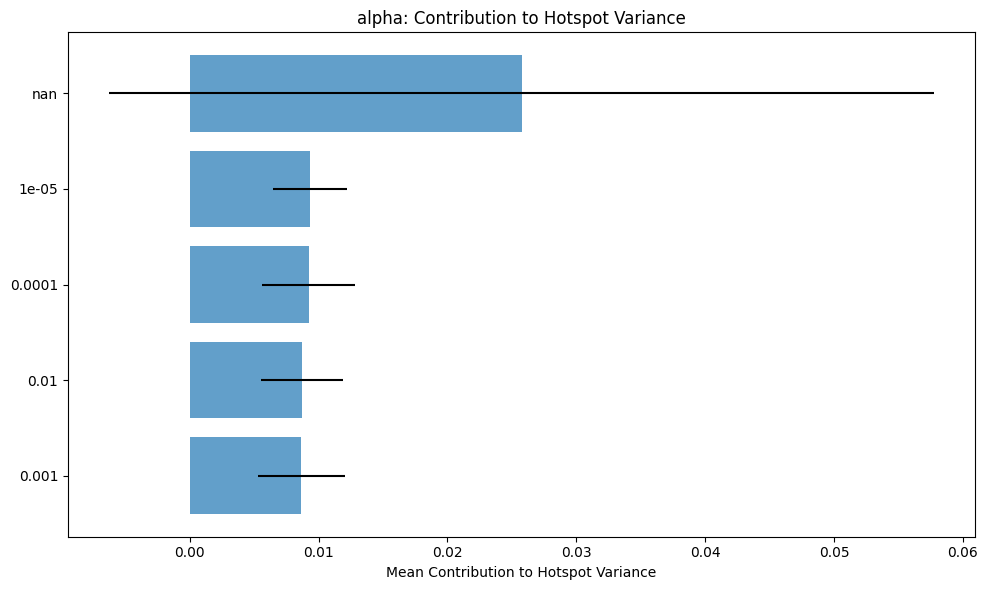


hidden_layer_sizes: Distribution in Hotspots vs Non-Hotspots

Mean contribution to hotspot variance by hidden_layer_sizes value:
                mean       std  count
hp_value                             
nan         0.025755  0.032001    200
(200, 100)  0.009903  0.004015     10
(50,)       0.009239  0.003282     10
(100, 50)   0.008984  0.003400     11
(100,)      0.008850  0.002824     11
(200,)      0.007612  0.001827      8


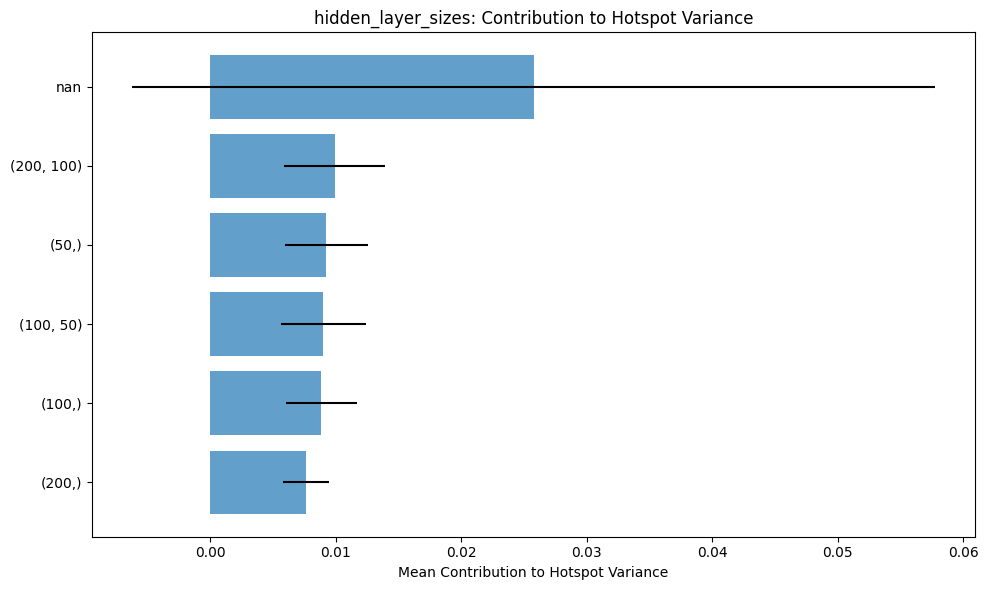


l1_ratio: Distribution in Hotspots vs Non-Hotspots

Mean contribution to hotspot variance by l1_ratio value:
              mean       std  count
hp_value                           
1.0       0.041987  0.042065      5
0.5       0.040591  0.037070      9
0.25      0.031087  0.034936     11
0.75      0.030768  0.033622     14
nan       0.020163  0.028188    200
0.0       0.019899  0.021628     11


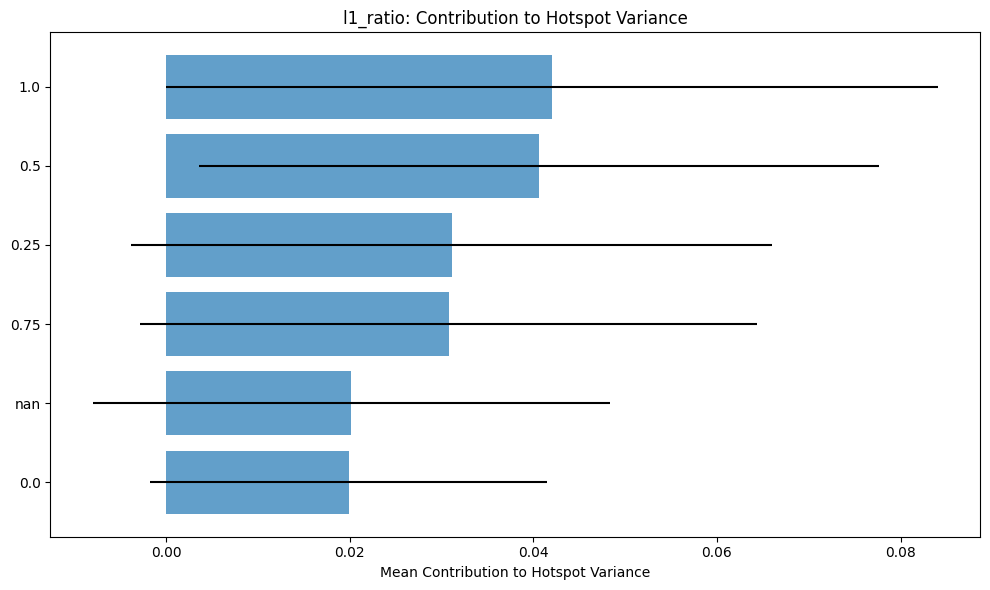


learning_rate: Distribution in Hotspots vs Non-Hotspots

Mean contribution to hotspot variance by learning_rate value:
              mean       std  count
hp_value                           
nan       0.025941  0.031691    200
0.1       0.011765  0.012241     15
0.2       0.008393  0.005081     11
0.01      0.007346  0.005434     14
0.05      0.003961  0.001090     10


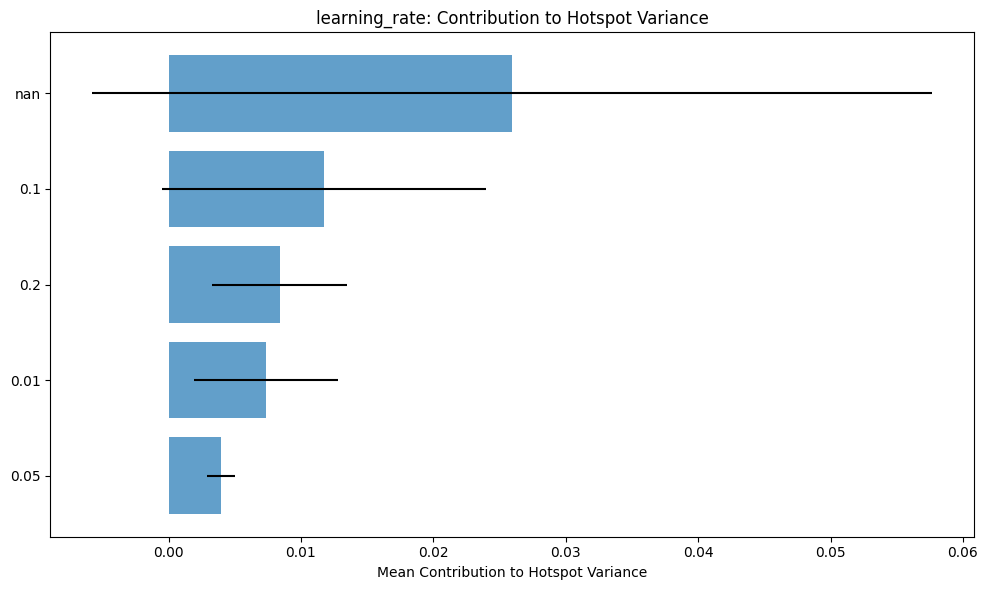


learning_rate_init: Distribution in Hotspots vs Non-Hotspots

Mean contribution to hotspot variance by learning_rate_init value:
              mean       std  count
hp_value                           
nan       0.025755  0.032001    200
0.0001    0.009717  0.003077     16
0.001     0.009330  0.002151     16
0.01      0.007986  0.003798     18


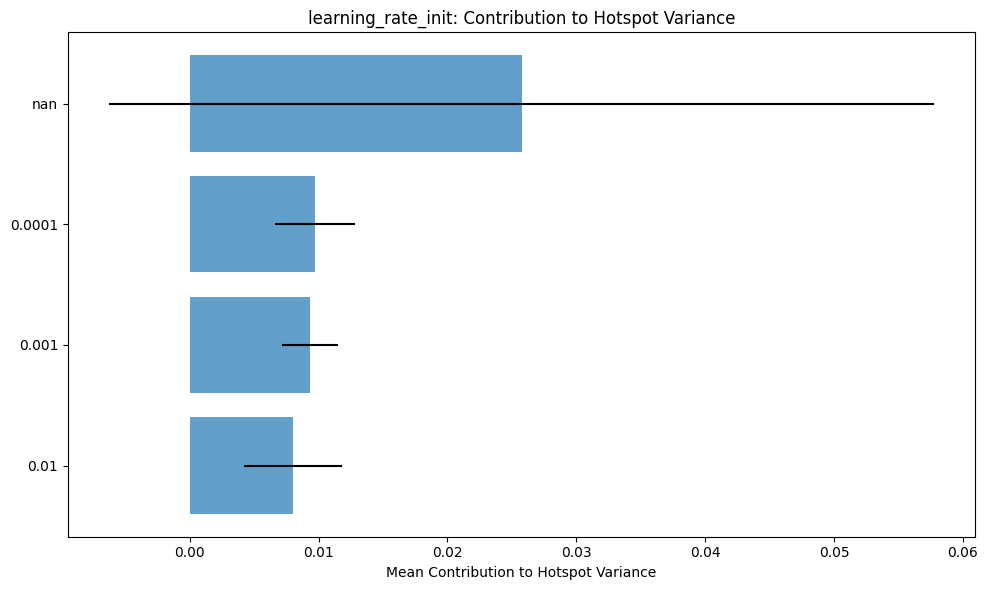


max_depth: Distribution in Hotspots vs Non-Hotspots

Mean contribution to hotspot variance by max_depth value:
              mean       std  count
hp_value                           
nan       0.030596  0.033938    157
20.0      0.016362  0.012759     11
40.0      0.013283  0.012596      9
5.0       0.008056  0.009624     25
4.0       0.007910  0.006424     14
2.0       0.006704  0.005812     10
3.0       0.006558  0.003528     15
10.0      0.002097  0.001161      9


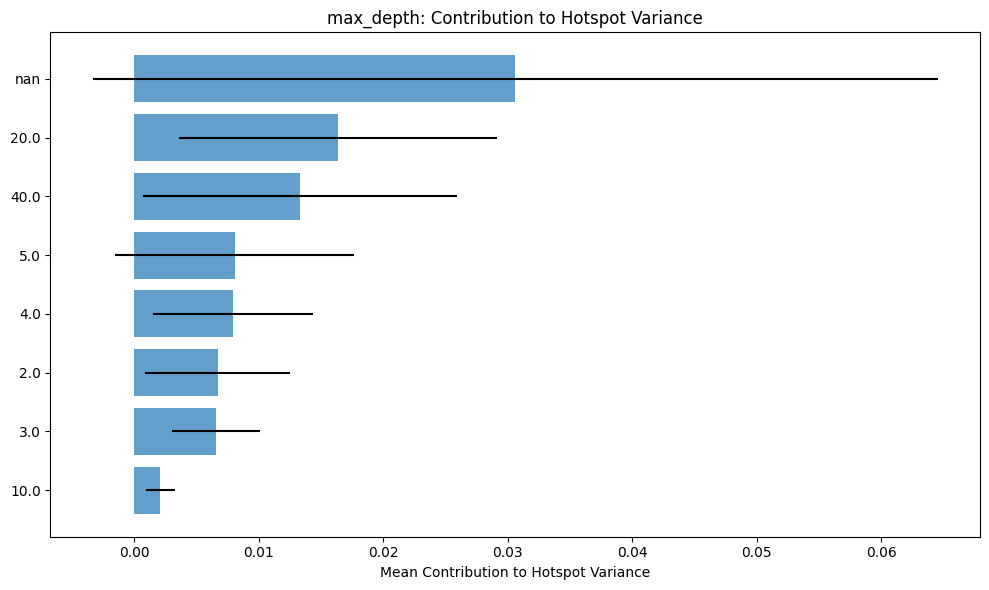


min_samples_leaf: Distribution in Hotspots vs Non-Hotspots

Mean contribution to hotspot variance by min_samples_leaf value:
              mean       std  count
hp_value                           
nan       0.025690  0.031683    200
1.0       0.013690  0.014227     18
2.0       0.009503  0.006699     16
4.0       0.003942  0.001244     16


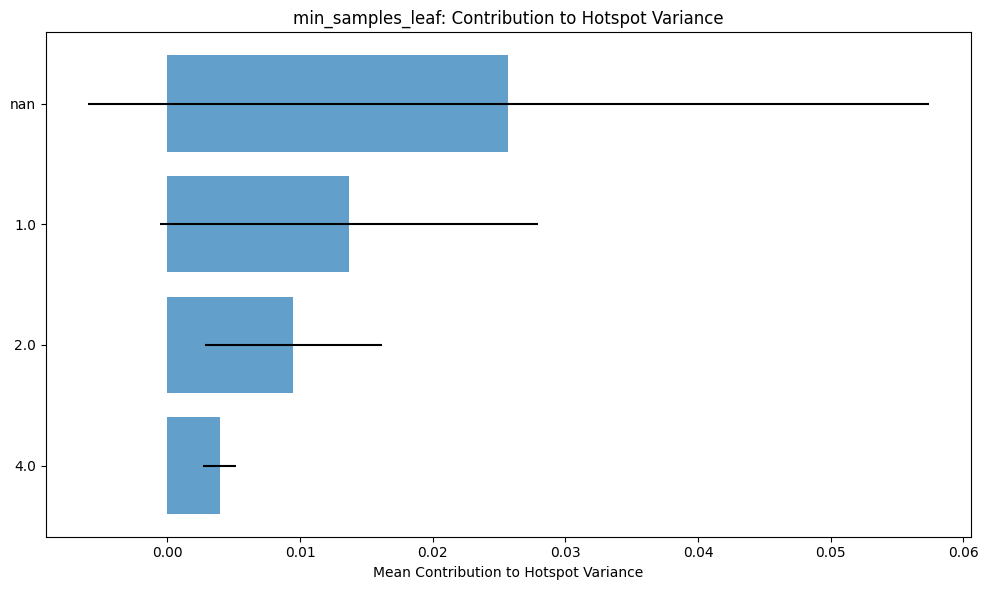


min_samples_split: Distribution in Hotspots vs Non-Hotspots

Mean contribution to hotspot variance by min_samples_split value:
              mean       std  count
hp_value                           
nan       0.025690  0.031683    200
2.0       0.011637  0.013756     18
5.0       0.009908  0.008832     18
10.0      0.005266  0.002301     14


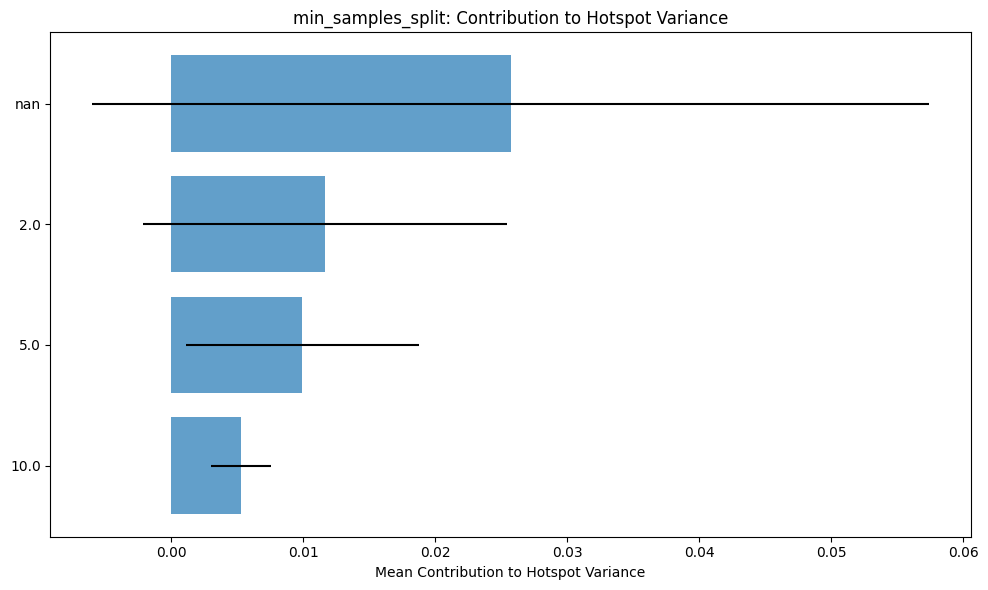


n_neighbors: Distribution in Hotspots vs Non-Hotspots

Mean contribution to hotspot variance by n_neighbors value:
              mean       std  count
hp_value                           
3.0       0.097848  0.016692      4
5.0       0.065956  0.021970      4
7.0       0.061088  0.027154      4
50.0      0.059236  0.043936      3
150.0     0.058544  0.045135      3
10.0      0.048907  0.041218      4
15.0      0.045886  0.044713      4
90.0      0.045633  0.045000      4
70.0      0.045584  0.045058      4
100.0     0.045250  0.045444      4


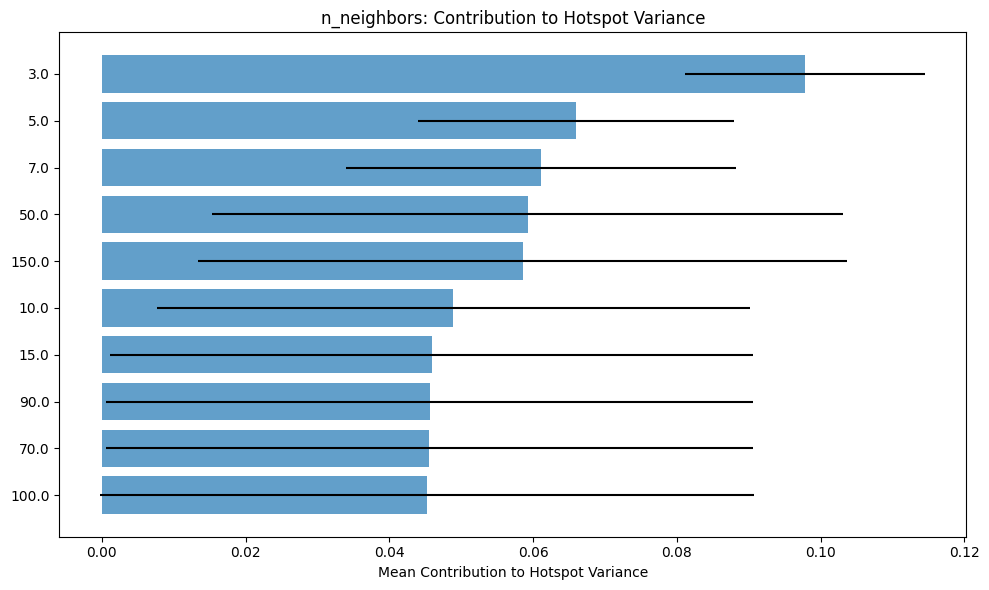


p: Distribution in Hotspots vs Non-Hotspots

Mean contribution to hotspot variance by p value:
              mean       std  count
hp_value                           
1.0       0.054908  0.039063     25
2.0       0.053547  0.038472     25
nan       0.014441  0.020057    200


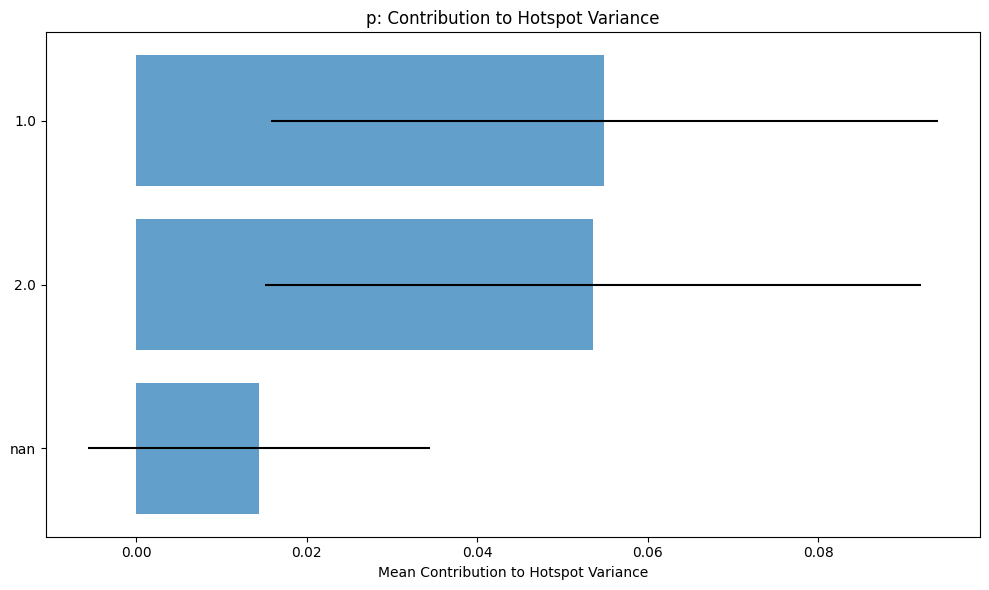


subsample: Distribution in Hotspots vs Non-Hotspots

Mean contribution to hotspot variance by subsample value:
              mean       std  count
hp_value                           
nan       0.025941  0.031691    200
0.8       0.009394  0.010151     16
1.0       0.007944  0.008097     21
0.6       0.007241  0.004454     13


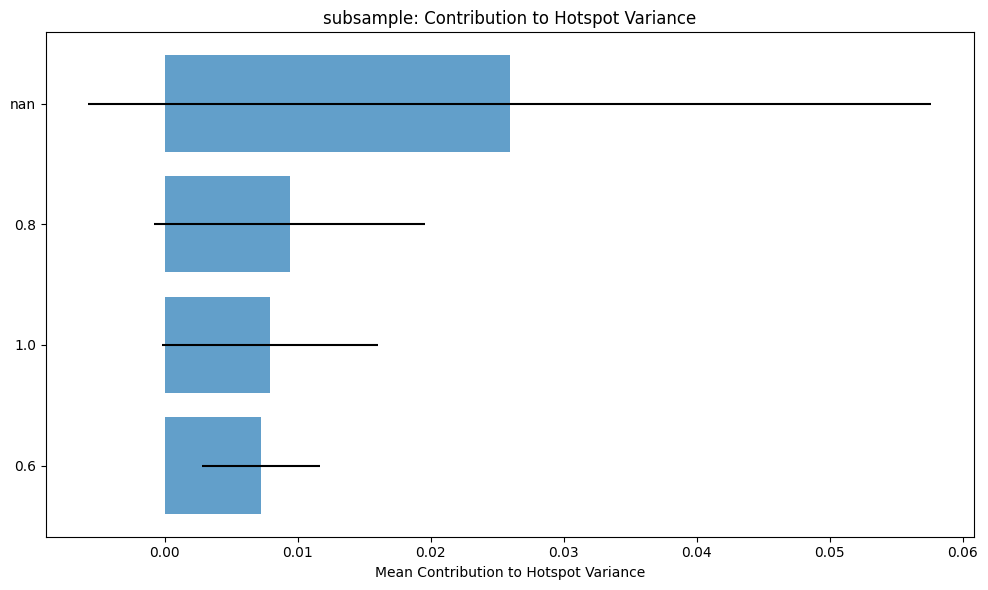


weights: Distribution in Hotspots vs Non-Hotspots

Mean contribution to hotspot variance by weights value:
              mean       std  count
hp_value                           
distance  0.084603  0.000000     26
uniform   0.021321  0.031061     24
nan       0.014441  0.020057    200


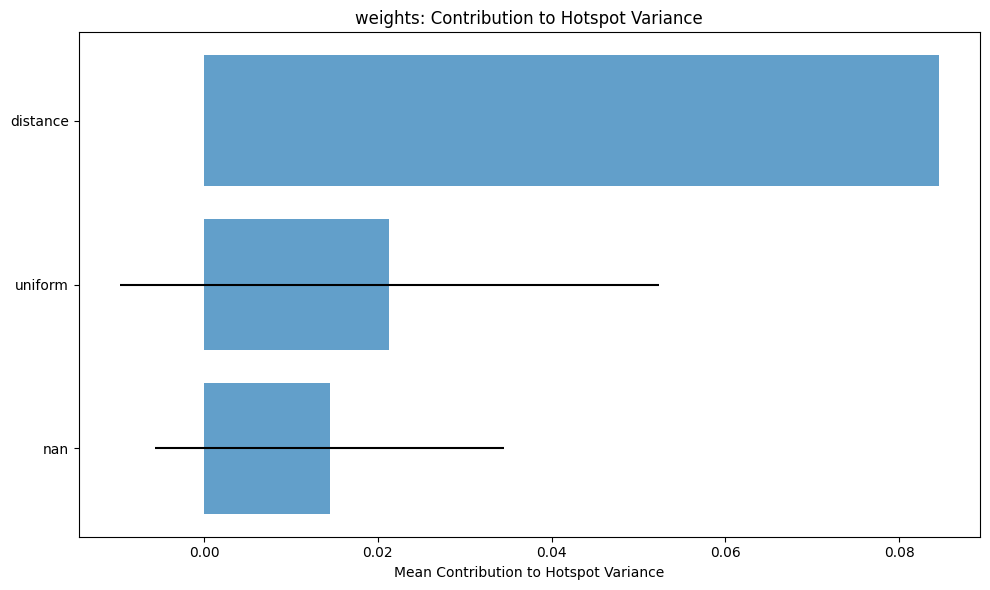

In [23]:
from analysis.spatial import build_knn_graph, lisa_local, extract_hh_components

# Sanity: hotspot analysis runs for at least 2 HPs
assert len(key_hps) >= 2, "Hotspot analysis requires at least 2 HPs in key_hps"

# Compute hotspots (use var_obs so variance vector is not shadowed in loops)
var_obs = metrics["variance"]
X_knn = X_test.select_dtypes(include=[np.number])
scaler_knn = StandardScaler()
X_knn_scaled = scaler_knn.fit_transform(X_knn)
W = build_knn_graph(X_knn_scaled, k=10, standardize=False)
lisa = lisa_local(var_obs, W)
hh_mask = lisa["cluster"].values == "HH"

print(f"Hotspot (HH) observations: {hh_mask.sum()} / {len(hh_mask)} ({hh_mask.mean()*100:.1f}%)\n")

# For each key hyperparameter, compare HP value distribution in hotspots vs non-hotspots
for hp_name in key_hps:
    print(f"\n{'='*60}")
    print(f"{hp_name}: Distribution in Hotspots vs Non-Hotspots")
    print(f"{'='*60}")
    
    try:
        hp_col = f'hp_{hp_name}' if f'hp_{hp_name}' in meta.columns else hp_name
        
        # Get HP values for each model (expand to observations)
        # For simplicity, we'll analyze at the model level: which HP values produce models
        # that contribute more to hotspot variance?
        
        # Compute per-model contribution to hotspot variance
        hotspot_variance = var_obs[hh_mask]
        model_contributions = []
        
        for i in range(P.shape[0]):
            # How much does this model's predictions differ from mean in hotspots?
            model_preds = P[i, :]
            mean_preds = np.mean(P, axis=0)
            hotspot_diff = np.mean((model_preds[hh_mask] - mean_preds[hh_mask]) ** 2)
            model_contributions.append(hotspot_diff)
        
        model_contributions = np.array(model_contributions)
        
        # Group by HP value (use make_hp_key to avoid numeric/string mixing)
        hp_values = meta[hp_col].values
        hp_values_hashable = [make_hp_key(hp_val) for hp_val in hp_values]
        
        hp_contrib = pd.DataFrame({
            'hp_value': hp_values_hashable,
            'contribution': model_contributions,
        }).groupby('hp_value')['contribution'].agg(['mean', 'std', 'count']).sort_values('mean', ascending=False)
        
        print(f"\nMean contribution to hotspot variance by {hp_name} value:")
        print(hp_contrib.head(10).to_string())
        
        # Visualize
        plt.figure(figsize=(10, 6))
        top_n = min(10, len(hp_contrib))
        top_hps = hp_contrib.head(top_n)
        plt.barh(range(len(top_hps)), top_hps['mean'], xerr=top_hps['std'], alpha=0.7)
        plt.yticks(range(len(top_hps)), top_hps.index)
        plt.xlabel('Mean Contribution to Hotspot Variance')
        plt.title(f'{hp_name}: Contribution to Hotspot Variance')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"  Error analyzing {hp_name} hotspot effects: {e}")

## 9. Takeaways

- **Var_between / Var_total** indicates how much a hyperparameter contributes to prediction variance
- **Var_within** captures variation due to random seeds or other HPs (given fixed HP value)
- **Local Rashomon sets** show which HP values admit multiple good models locally
- **Hotspot analysis** reveals if certain HP values are associated with high-variance regions

**Key insight**: Hyperparameter effects are defined **conditionally on the Rashomon set** - we only analyze models that are globally good (L â‰¤ L* + Îµ), then decompose variance within that set.